# Visualizing comprehensive regression results 10/21/2025

In [1]:
import warnings
from arivale_data_interface import get_snapshot
import pandas as pd
import numpy as np
import scipy
import json

warnings.simplefilter("ignore")

#import the final master sleep_merged df and the features_dict

sleep_merged = pd.read_csv('../working_df/sleep_merged_sleep_meds_excluded_10_14_2025.csv', dtype={'public_client_id': object})

with open('../working_df/features_dict.json', 'r') as f:
    features_dict = json.load(f)

# Open all the unadjusted and the cognate adjusted results for each feature set

In [1]:
feature_sets = [
    'digestion_features',
    'diet_daily_features',
    'supplement_features',
    'diversity_features',
    'new_microbe_features',
    'new_microbe_binarized_features',
    'metabolite_features_log',
    'clinical_features_log1p',
    'proteomics_features',
    'micom_features_log'
]

In [4]:
# Opening regression results for 08/25/2025 with the additional season and weekend-weekday ratio covariates
import pandas as pd
import numpy as np

# For annotating proteomics and metabolomics dfs
new_anns = pd.read_excel("new_metabolomics_metadata_updated_v2.xlsx")
new_anns["independent_feature"] = "metabolite_" + new_anns.CHEM_ID.astype(str) + "_log"
new_anns.rename(columns={"CHEMICAL_NAME": "BIOCHEMICAL_NAME"}, inplace=True)
new_anns_name_dict = dict(zip(new_anns["independent_feature"], new_anns["BIOCHEMICAL_NAME"]))

anns = get_snapshot("metabolomics_metadata").iloc[:, 0:8]
anns["independent_feature"] = "metabolite_" + anns.CHEMICAL_ID.astype(str) + "_log"

anns["BIOCHEMICAL_NAME"] = anns.apply(
    lambda row: new_anns_name_dict[row["independent_feature"]]
    if row["independent_feature"] in new_anns_name_dict and new_anns_name_dict[row["independent_feature"]] != row["BIOCHEMICAL_NAME"]
    else row["BIOCHEMICAL_NAME"],
    axis=1
)
metabolite_anns_dict = dict(zip(anns["independent_feature"], anns["BIOCHEMICAL_NAME"]))

proteomics_metadata = get_snapshot("proteomics_metadata")
proteomics_name_dict = dict(zip(proteomics_metadata["name"], proteomics_metadata["gene_description"]))

# Open the dict with the micom codes to names
with open('../independent_feature_dataframes/micom_features_codes_to_names.json', 'r') as f:
    micom_name_dict = json.load(f)
# Add log to the key names
micom_name_dict = {f"{k}_log": v for k, v in micom_name_dict.items()}

# Main output dictionary
unique_hits_by_feature = {}

for feature_set in feature_sets:
    print(feature_set)

    df1 = pd.read_csv(f'lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/{feature_set}_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv')
    df2 = pd.read_csv(f'lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/{feature_set}_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv')

    # Update names
    if 'metabolite' in feature_set:
        df1['independent_feature'] = df1['independent_feature'].map(metabolite_anns_dict).fillna(df1['independent_feature'])
        df2['independent_feature'] = df2['independent_feature'].map(metabolite_anns_dict).fillna(df2['independent_feature'])
    elif 'proteomics' in feature_set:
        #df1['independent_feature'] = df1['independent_feature'].map(proteomics_name_dict).fillna(df1['independent_feature'])
        #df2['independent_feature'] = df2['independent_feature'].map(proteomics_name_dict).fillna(df2['independent_feature'])

        df1['independent_feature'] = (
            df1['independent_feature']
            .apply(lambda x: f"{proteomics_name_dict.get(x, x)}|{x}")
            ).fillna(df1['independent_feature'])
        df2['independent_feature'] = (
            df2['independent_feature']
            .apply(lambda x: f"{proteomics_name_dict.get(x, x)}|{x}")
            ).fillna(df2['independent_feature'])

        
    elif 'micom' in feature_set:
        df1['independent_feature'] = df1['independent_feature'].map(micom_name_dict).fillna(df1['independent_feature'])
        df2['independent_feature'] = df2['independent_feature'].map(micom_name_dict).fillna(df2['independent_feature'])

    # Filter hits by q-value threshold
    #df1 = df1[df1.q < 0.1].copy()
    #df2 = df2[df2.q < 0.1].copy()

    # Compute beta sign for merging purposes
    df1['beta_sign'] = np.sign(df1['beta'])
    df2['beta_sign'] = np.sign(df2['beta'])

    # Rename columns to distinguish adjusted/unadjusted
    df1.rename(columns={
        # Keep this or not
        'n_train': 'n_adjusted',
        ###
        'beta': 'beta_adjusted',
        't_statistic': 't_statistic_adjusted',
        'p': 'p_adjusted',
        'q': 'q_adjusted'
    }, inplace=True)

    df2.rename(columns={
        # Keep this or not
        'n_train': 'n_unadjusted',
        ###
        'beta': 'beta_unadjusted',
        't_statistic': 't_statistic_unadjusted',
        'p': 'p_unadjusted',
        'q': 'q_unadjusted'
    }, inplace=True)

    # Merge into wide format using outer join to preserve all hits
    merged = pd.merge(
        df1[['dependent_feature', 'independent_feature', 'beta_sign', 'beta_adjusted', 't_statistic_adjusted', 'p_adjusted', 'q_adjusted', 'n_adjusted']],
        df2[['dependent_feature', 'independent_feature', 'beta_sign', 'beta_unadjusted', 't_statistic_unadjusted', 'p_unadjusted', 'q_unadjusted', 'n_unadjusted']],
        on=['dependent_feature', 'independent_feature', 'beta_sign'],
        how='outer'
    )
    """
    # Mark presence in each model
    merged['from_adjusted'] = merged['beta_adjusted'].notna().astype(int)
    merged['from_unadjusted'] = merged['beta_unadjusted'].notna().astype(int)
    merged['shared_hit'] = ((merged['from_adjusted'] == 1) & (merged['from_unadjusted'] == 1)).astype(int)
    """
    
    # Mark q < 0.1 significance, preserving NaNs
    merged['from_adjusted'] = merged['q_adjusted'].apply(
        lambda q: 1 if q < 0.1 else 0 if pd.notna(q) else np.nan
    )
    
    merged['from_unadjusted'] = merged['q_unadjusted'].apply(
        lambda q: 1 if q < 0.1 else 0 if pd.notna(q) else np.nan
    )
    
    # shared_hit = 1 only if both are 1 (not NaN)
    merged['shared_hit'] = ((merged['from_adjusted'] == 1) & (merged['from_unadjusted'] == 1)).astype(int)


    # Compute change in t-statistic magnitude and direction
    merged['t_delta'] = merged.apply(
        lambda row: abs(row['t_statistic_adjusted']) - abs(row['t_statistic_unadjusted'])
        if pd.notna(row['t_statistic_adjusted']) and pd.notna(row['t_statistic_unadjusted']) else np.nan,
        axis=1
    )
    merged['t_direction'] = merged['t_delta'].apply(
        lambda x: 'stronger' if x > 0 else 'weaker' if x < 0 else 'no_change' if pd.notna(x) else np.nan
    )

    unique_hits_by_feature[feature_set] = merged

digestion_features
diet_daily_features
supplement_features
diversity_features
new_microbe_features
new_microbe_binarized_features
metabolite_features_log
clinical_features_log1p
proteomics_features
micom_features_log


In [22]:
unique_hits_by_feature['diet_daily_features'].groupby('dependent_feature').independent_feature.nunique()

dependent_feature
bedtime_int_log1p_resid                     44
bedtime_int_std_log1p_resid                 44
sleep_awakeningsCount_log1p_resid           44
sleep_awakeningsCount_std_log1p_resid       44
sleep_efficiency_log1p_resid                44
sleep_efficiency_std_log1p_resid            44
sleep_minutesAfterWakeup_log1p_resid        44
sleep_minutesAfterWakeup_std_log1p_resid    44
Name: independent_feature, dtype: int64

In [24]:
unique_hits_by_feature['diet_daily_features'].dependent_feature.nunique()

8

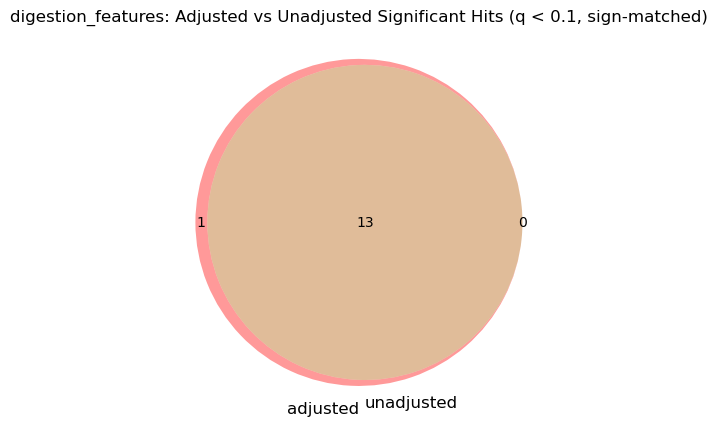

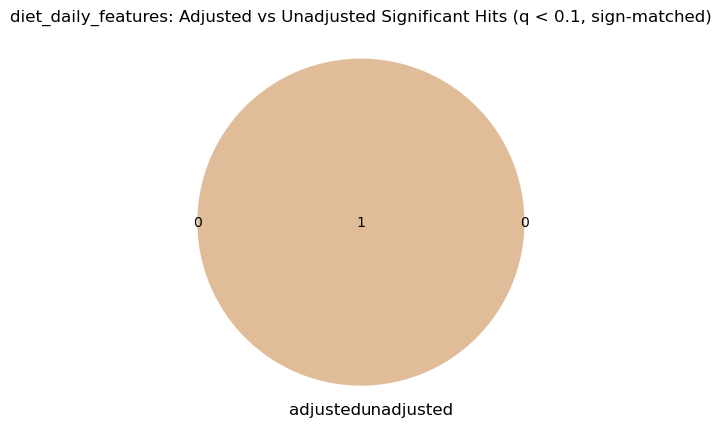

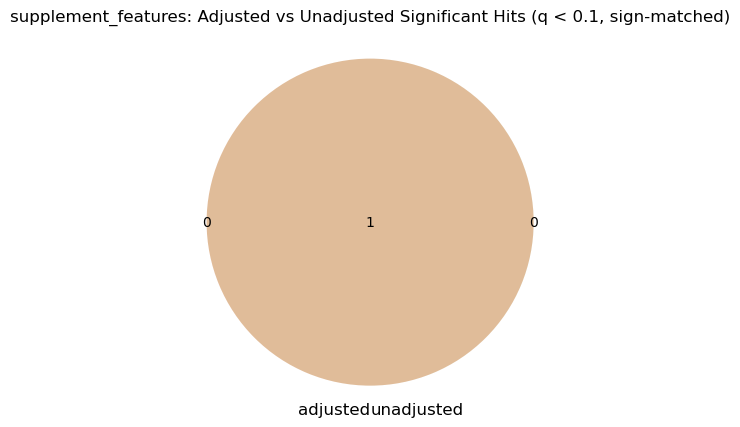

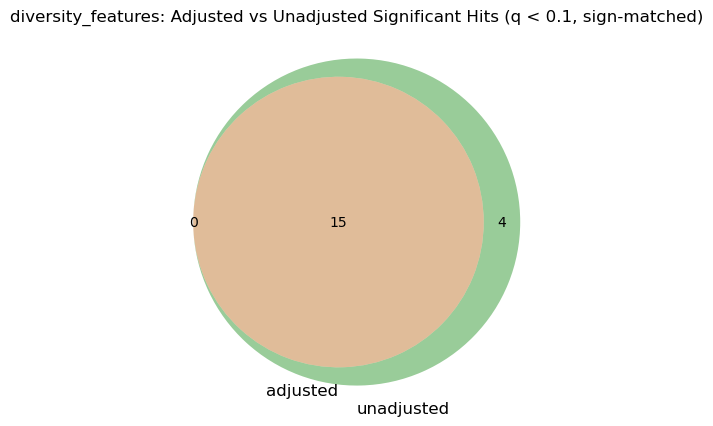

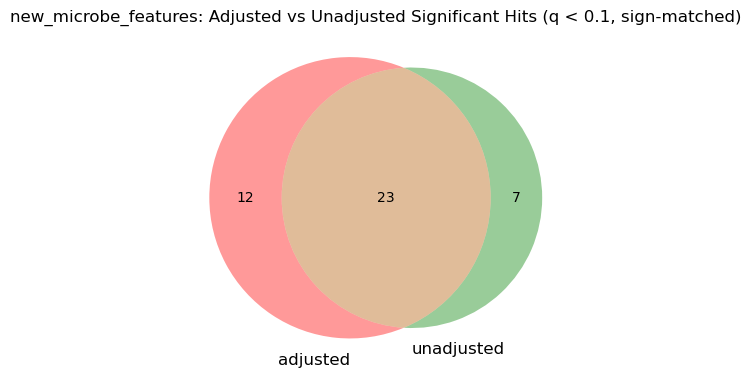

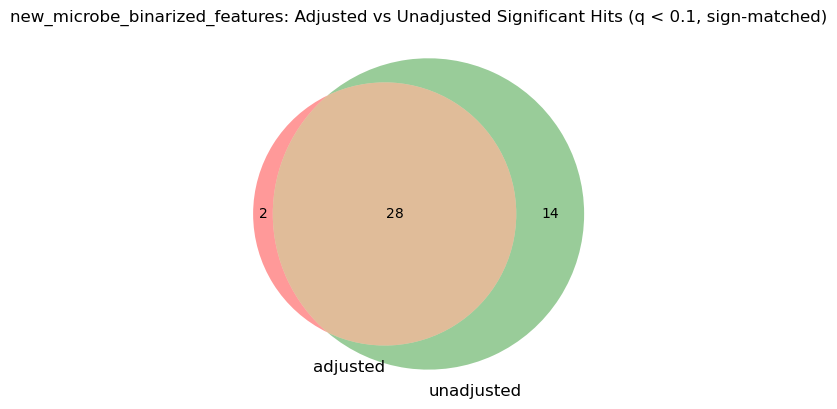

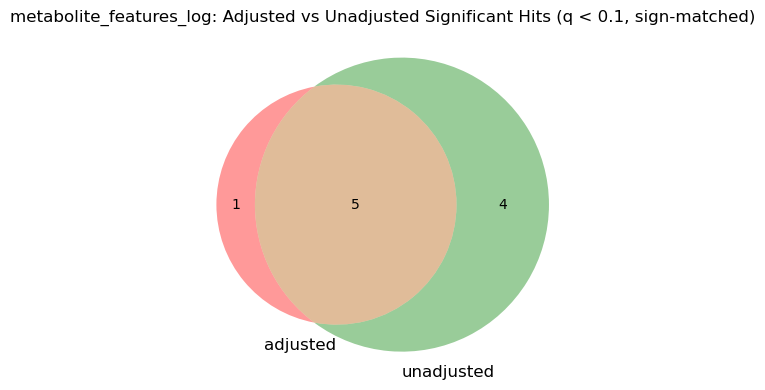

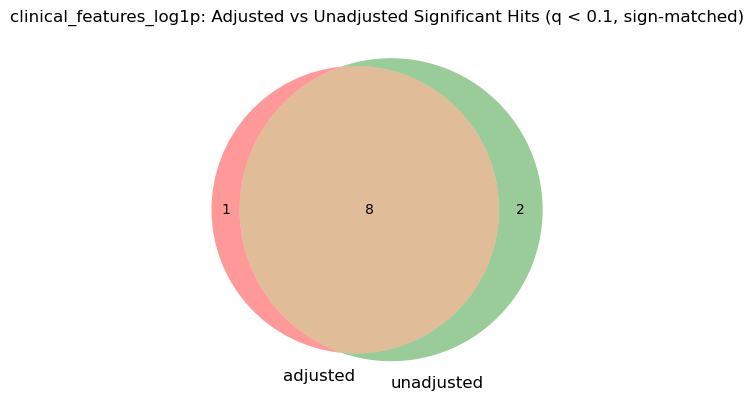

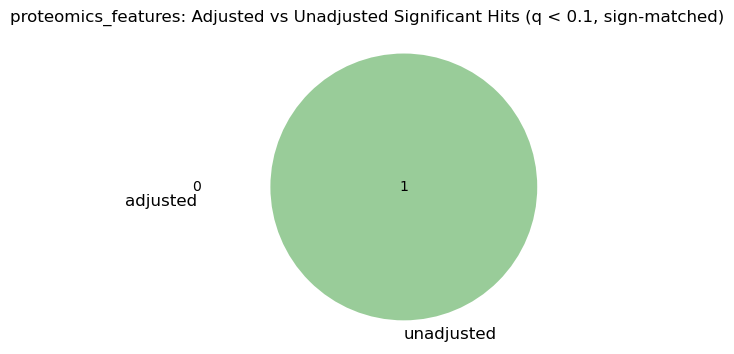

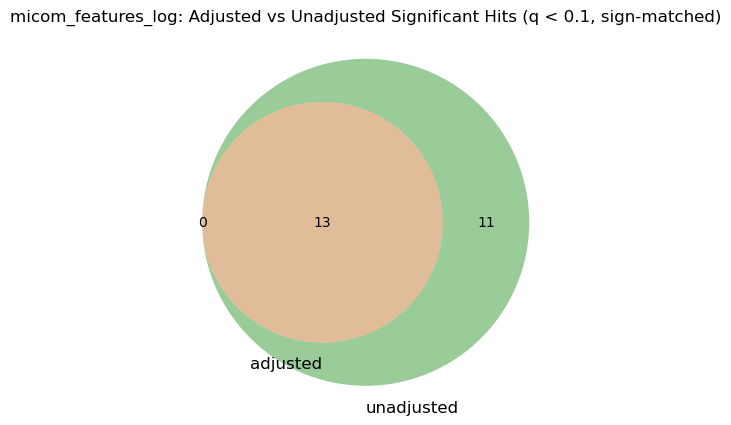

In [6]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import numpy as np

for feature_set, combined_df in unique_hits_by_feature.items():
    
    # Make sets for adjusted and unadjusted hits (q < 0.1 and notna)
    #combined_df = combined_df[(combined_df.q_adjusted < 0.1) | (combined_df.q_unadjusted < 0.1)]
    adjusted_hits = combined_df[(combined_df['from_adjusted'] == 1) & (combined_df.q_adjusted < 0.1)]
    unadjusted_hits = combined_df[(combined_df['from_unadjusted'] == 1) & (combined_df.q_unadjusted < 0.1)]

    # Define sets using matched beta_sign
    set_adjusted = set(zip(adjusted_hits['dependent_feature'],
                           adjusted_hits['independent_feature'],
                           adjusted_hits['beta_sign']))
    
    set_unadjusted = set(zip(unadjusted_hits['dependent_feature'],
                             unadjusted_hits['independent_feature'],
                             unadjusted_hits['beta_sign']))

    # Plot Venn diagram
    plt.figure(figsize=(5, 5))
    venn2([set_adjusted, set_unadjusted], set_labels=('adjusted', 'unadjusted'))
    plt.title(f"{feature_set}: Adjusted vs Unadjusted Significant Hits (q < 0.1, sign-matched)")
    plt.show()

# Volcano Plots showing unadjusted and adjusted hits grouped by feature set

In [7]:
import altair as alt
import numpy as np
import pandas as pd

for feature_set in feature_sets:
    merged = unique_hits_by_feature[feature_set].copy()
    # Find all the entries where q, either adjusted or unadjusted, is less than 0.1
    merged = merged[(merged.q_adjusted < 0.1) | (merged.q_unadjusted < 0.1)]

    # ----------------------------------------------
    # 1.  Label hit category
    # ----------------------------------------------
    def label_hit(row):
        if row['shared_hit'] == 1:
            return 'shared'
        elif row['from_adjusted'] == 1:
            return 'adjusted_only'
        elif row['from_unadjusted'] == 1:
            return 'unadjusted_only'
        else:
            return 'ERROR neither'

    merged['hit_category'] = merged.apply(label_hit, axis=1)

    # ----------------------------------------------
    # 2.  Plot variables
    #    • use adjusted values when available
    # ----------------------------------------------
    merged['plot_t_statistic'] = merged.apply(
        lambda r: r['t_statistic_adjusted'] if r['from_adjusted'] == 1 else r['t_statistic_unadjusted'],
        axis=1
    )
    merged['plot_logq'] = merged.apply(
        lambda r: -np.log10(r['q_adjusted']) if r['from_adjusted'] == 1 else -np.log10(r['q_unadjusted']),
        axis=1
    )

    # ----------------------------------------------
    # 3.  Triangle direction & size
    # ----------------------------------------------
    merged['plot_shape'] = merged['t_direction'].fillna('missing_adjusted_model')

    # Size:  use abs(t_delta); non-shared (NaN) → 0
    merged['abs_t_delta'] = merged['t_delta'].abs().fillna(0)

    # ----------------------------------------------
    # 4.  Volcano plot
    # ----------------------------------------------
    volcano = (
        alt.Chart(merged)
        .mark_point()
        .encode(
            x=alt.X('plot_t_statistic:Q', title='t-statistic (adjusted if available)'),
            y=alt.Y('plot_logq:Q', title='-log10(q-value, adjusted if available)'),
            color=alt.Color('hit_category:N',
                            scale=alt.Scale(domain=['shared', 'adjusted_only', 'unadjusted_only'],
                                            range=['orange', 'purple', 'blue']),
                            legend=alt.Legend(title='Hit Category')),
            shape=alt.Shape('plot_shape:N',
                            scale=alt.Scale(domain=['stronger', 'weaker', 'missing adjusted model'],
                                            range=['triangle-up', 'triangle-down', 'circle']),
                            legend=alt.Legend(title='Adjustment Effect')),
            size=alt.Size('abs_t_delta:Q',
                          scale=alt.Scale(range=[60, 200]),
                          legend=alt.Legend(title='delta t (adj vs unadj)')),
            tooltip=[
                alt.Tooltip('independent_feature:N', title='Feature'),
                alt.Tooltip('dependent_feature:N', title='Sleep Outcome'),
                alt.Tooltip('plot_t_statistic:Q', format='.3f'),
                alt.Tooltip('plot_logq:Q', title='-log10(q)', format='.2f'),
                alt.Tooltip('hit_category:N'),
                alt.Tooltip('t_direction:N', title='Adj vs Unadj'),
                alt.Tooltip('abs_t_delta:Q', title='delta t', format='.3f')
            ]
        )
        .properties(
            title=f'Volcano Plot: {feature_set} → Sleep Hits',
            width=700,
            height=400
        )
        .interactive()
    )

    zero_line = alt.Chart(pd.DataFrame({'x': [0]})).mark_rule(
        strokeDash=[4, 4], color='black'
    ).encode(x='x:Q')

    print(f'{feature_set}, Dependent sleep feature distribution for shared:')
    print(merged[merged.hit_category == 'shared'].dependent_feature.value_counts())
    print('')
    print('Adjustment Effect Distribution')
    print(merged.plot_shape.value_counts())
    display(zero_line + volcano)

digestion_features, Dependent sleep feature distribution for shared:
dependent_feature
sleep_restlessDuration_std_log1p_resid    4
sleep_restlessDuration_log1p_resid        2
bedtime_int_std_log1p_resid               2
sleep_timeInBed_log1p_resid               2
bedtime_int_log1p_resid                   1
sleep_minutesAsleep_std_log1p_resid       1
sleep_timeInBed_std_log1p_resid           1
Name: count, dtype: int64

Adjustment Effect Distribution
plot_shape
weaker      10
stronger     4
Name: count, dtype: int64


alt.LayerChart(...)

diet_daily_features, Dependent sleep feature distribution for shared:
dependent_feature
bedtime_int_std_log1p_resid    1
Name: count, dtype: int64

Adjustment Effect Distribution
plot_shape
weaker    1
Name: count, dtype: int64


alt.LayerChart(...)

supplement_features, Dependent sleep feature distribution for shared:
dependent_feature
sleep_awakeningsCount_std_log1p_resid    1
Name: count, dtype: int64

Adjustment Effect Distribution
plot_shape
stronger    1
Name: count, dtype: int64


...

alt.LayerChart(...)

proteomics_features, Dependent sleep feature distribution for shared:
Series([], Name: count, dtype: int64)

Adjustment Effect Distribution
plot_shape
weaker    1
Name: count, dtype: int64


alt.LayerChart(...)

micom_features_log, Dependent sleep feature distribution for shared:
dependent_feature
sleep_minutesAsleep_log1p_resid             7
sleep_efficiency_log1p_resid                3
sleep_awakeDuration_std_log1p_resid         1
sleep_minutesAfterWakeup_log1p_resid        1
sleep_minutesAfterWakeup_std_log1p_resid    1
Name: count, dtype: int64

Adjustment Effect Distribution
plot_shape
weaker                    16
stronger                   7
missing_adjusted_model     1
Name: count, dtype: int64


alt.LayerChart(...)

# Bar chart summaries of hits SHARED between adjusted and unadjusted

## Organize sleep features into larger groupings for broader interpretation of results

In [8]:
# Organize sleep variables into higher level groups:
sleep_duration_variables = ['sleep_minutesAsleep_log1p_resid',
                            'sleep_timeInBed_log1p_resid']
sleep_disruption_variables = ['sleep_awakeningsCount_log1p_resid',
                              'sleep_minutesAwake_log1p_resid',
                              'sleep_awakeDuration_log1p_resid',
                              'sleep_restlessDuration_log1p_resid',
                              'sleep_minutesAfterWakeup_log1p_resid']
sleep_duration_variability_variables = ['sleep_minutesAsleep_std_log1p_resid',
                                        'sleep_timeInBed_std_log1p_resid']
sleep_disruption_variability_variables = ['sleep_awakeningsCount_std_log1p_resid',
                                          'sleep_minutesAwake_std_log1p_resid',
                                          'sleep_awakeDuration_std_log1p_resid',
                                          'sleep_restlessDuration_std_log1p_resid',
                                          'sleep_minutesAfterWakeup_std_log1p_resid'] 
sleep_bedtime_variables = ['bedtime_int_log1p_resid']
sleep_bedtime_variability_variables = ['bedtime_int_std_log1p_resid']
sleep_efficiency_variables = ['sleep_efficiency_log1p_resid']
sleep_efficiency_variability_variables = ['sleep_efficiency_std_log1p_resid']

In [9]:
# Sleep feature group mapping
sleep_feature_group_map = {
    **{v: 'Sleep Duration' for v in sleep_duration_variables},
    **{v: 'Sleep Duration Variability' for v in sleep_duration_variability_variables},
    **{v: 'Sleep Disruption' for v in sleep_disruption_variables},
    **{v: 'Sleep Disruption Variability' for v in sleep_disruption_variability_variables},
    **{'bedtime_int_log1p_resid': 'Bedtime'},
    **{'bedtime_int_std_log1p_resid': 'Bedtime Variability'},
    **{'sleep_efficiency_log1p_resid': 'Sleep Efficiency'},
    **{'sleep_efficiency_std_log1p_resid': 'Sleep Efficiency Variability'}
}

## Create the combined df that combines all the adjusted and unadjusted results for easier plotting

In [10]:
# Annotated list for combining
combined_with_groups = []

for feature_set, df in unique_hits_by_feature.items():
    df = df.copy()
    df['feature_set'] = feature_set  # add omic set label
    df['sleep_group'] = df['dependent_feature'].map(sleep_feature_group_map)
    combined_with_groups.append(df)

# Create the combined df that combines all the adjusted and unadjusted results for easier plotting
combined_df = pd.concat(combined_with_groups, ignore_index=True)

In [11]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40988 entries, 0 to 40987
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dependent_feature       40988 non-null  object 
 1   independent_feature     40988 non-null  object 
 2   beta_sign               40988 non-null  float64
 3   beta_adjusted           37256 non-null  float64
 4   t_statistic_adjusted    37256 non-null  float64
 5   p_adjusted              37256 non-null  float64
 6   q_adjusted              37256 non-null  float64
 7   n_adjusted              37256 non-null  float64
 8   beta_unadjusted         38858 non-null  float64
 9   t_statistic_unadjusted  38858 non-null  float64
 10  p_unadjusted            38858 non-null  float64
 11  q_unadjusted            38858 non-null  float64
 12  n_unadjusted            38858 non-null  float64
 13  from_adjusted           37256 non-null  float64
 14  from_unadjusted         38858 non-null

In [12]:
combined_df[combined_df.shared_hit == 1].dependent_feature.value_counts()

dependent_feature
sleep_awakeDuration_log1p_resid             25
sleep_minutesAsleep_log1p_resid             24
sleep_timeInBed_log1p_resid                 10
sleep_awakeDuration_std_log1p_resid          9
sleep_efficiency_log1p_resid                 6
sleep_restlessDuration_std_log1p_resid       5
sleep_minutesAwake_log1p_resid               5
sleep_minutesAwake_std_log1p_resid           4
bedtime_int_std_log1p_resid                  3
sleep_minutesAsleep_std_log1p_resid          3
sleep_awakeningsCount_log1p_resid            3
bedtime_int_log1p_resid                      2
sleep_restlessDuration_log1p_resid           2
sleep_minutesAfterWakeup_std_log1p_resid     2
sleep_minutesAfterWakeup_log1p_resid         2
sleep_awakeningsCount_std_log1p_resid        1
sleep_timeInBed_std_log1p_resid              1
Name: count, dtype: int64

## Drop down to ONLY the test results where tests were run for both unadjusted AND adjusted

In [13]:
# Drop down to ONLY the adjusted set of tests, this will be the smaller of the test sets
# bc the adjusted didn't run as many regressions due to more covariates
combined_df = combined_df.dropna(subset='n_adjusted')

## Create a bar chart showing the total models/tests fit and the number of hits per sleep group for each feature set

In [14]:
# Total tests per omic and sleep group
total_tests = (
    combined_df.groupby(['feature_set', 'sleep_group'])
    .size()
    .reset_index(name='n_tests')
)

# Shared hits (q<0.1 in both adjusted and unadjusted) per omic and sleep group
shared_hits = (
    combined_df[combined_df['shared_hit'] == 1]
    .groupby(['feature_set', 'sleep_group'])
    .size()
    .reset_index(name='n_hits')
)

# Merge and compute hit rate
shared_hit_rate_df = pd.merge(total_tests, shared_hits, on=['feature_set', 'sleep_group'], how='left')
shared_hit_rate_df['n_hits'] = shared_hit_rate_df['n_hits'].fillna(0).astype(int)
shared_hit_rate_df['hit_rate'] = shared_hit_rate_df['n_hits'] / shared_hit_rate_df['n_tests'] * 100

In [15]:
# This corresponds to the total number of regressions fit for each feature set
combined_df.feature_set.value_counts()

feature_set
metabolite_features_log           20788
proteomics_features                4948
micom_features_log                 3534
new_microbe_features               2744
new_microbe_binarized_features     2714
clinical_features_log1p            1770
diet_daily_features                 352
digestion_features                  262
supplement_features                  90
diversity_features                   54
Name: count, dtype: int64

In [16]:
# This is the total number of regressions fit (count), and the N mean and std for models fit for a given feature set
round(combined_df.groupby('feature_set').n_adjusted.describe())

,count,mean,std,min,25%,50%,75%,max
feature_set,,,,,,,,
clinical_features_log1p,1770.0,689.0,356.0,163.0,408.0,734.0,1127.0,1147.0
diet_daily_features,352.0,192.0,2.0,178.0,193.0,193.0,193.0,193.0
digestion_features,262.0,824.0,328.0,283.0,576.0,797.0,1072.0,1293.0
diversity_features,54.0,1063.0,396.0,497.0,898.0,898.0,1469.0,1469.0
metabolite_features_log,20788.0,474.0,179.0,159.0,264.0,470.0,684.0,720.0
micom_features_log,3534.0,968.0,407.0,171.0,497.0,898.0,1466.0,1469.0
new_microbe_binarized_features,2714.0,1064.0,392.0,497.0,898.0,898.0,1469.0,1469.0
new_microbe_features,2744.0,636.0,373.0,170.0,325.0,509.0,875.0,1469.0
proteomics_features,4948.0,656.0,213.0,215.0,583.0,584.0,872.0,873.0


In [17]:
# This is the distribution of N for the set of significant features grouped by feature set
round(combined_df[combined_df.shared_hit == 1].groupby('feature_set').n_adjusted.describe())

,count,mean,std,min,25%,50%,75%,max
feature_set,,,,,,,,
clinical_features_log1p,8.0,400.0,4.0,399.0,399.0,399.0,399.0,410.0
diet_daily_features,1.0,190.0,NaN,190.0,190.0,190.0,190.0,190.0
digestion_features,13.0,674.0,291.0,283.0,575.0,576.0,797.0,1072.0
diversity_features,15.0,932.0,321.0,497.0,898.0,898.0,898.0,1469.0
metabolite_features_log,5.0,430.0,174.0,227.0,402.0,402.0,407.0,710.0
micom_features_log,13.0,1114.0,291.0,880.0,898.0,898.0,1468.0,1469.0
new_microbe_binarized_features,28.0,959.0,180.0,898.0,898.0,898.0,898.0,1469.0
new_microbe_features,23.0,684.0,211.0,253.0,492.0,780.0,874.0,897.0
supplement_features,1.0,1469.0,NaN,1469.0,1469.0,1469.0,1469.0,1469.0


In [18]:
# This is the number of unique features within a feature set that were tested
combined_df.groupby('feature_set').independent_feature.nunique()

feature_set
clinical_features_log1p            104
diet_daily_features                 44
digestion_features                  16
diversity_features                   3
metabolite_features_log           1191
micom_features_log                 201
new_microbe_binarized_features     154
new_microbe_features               177
proteomics_features                276
supplement_features                  5
Name: independent_feature, dtype: int64

In [19]:
# This is the number of unique sleep features tested as outcomes. Only diet didn't meet the requirements for fitting all sleep features
combined_df.groupby('feature_set').dependent_feature.nunique()

feature_set
clinical_features_log1p           18
diet_daily_features                8
digestion_features                18
diversity_features                18
metabolite_features_log           18
micom_features_log                18
new_microbe_binarized_features    18
new_microbe_features              18
proteomics_features               18
supplement_features               18
Name: dependent_feature, dtype: int64

In [23]:
# What FELL OUT of significance after additional adjustments in Model B (ie present in A but NOT in B)?
sig_in_A_but_not_B = combined_df[
    (combined_df.shared_hit != 1) &
    (combined_df.from_unadjusted == 1)
]

for feature_set, group in sig_in_A_but_not_B.groupby('feature_set'):
    print("\n===============================")
    print(f"Feature set: {feature_set}")
    print("===============================")

    display_cols = ['dependent_feature', 'independent_feature', 'beta_sign']

    # Print empty message or table
    if group.empty:
        print("No associations present in Model B but not in Model A.")
    else:
        print(group[display_cols].to_string(index=False))


Feature set: clinical_features_log1p
                 dependent_feature independent_feature  beta_sign
sleep_minutesAwake_std_log1p_resid       homa_ir_log1p        1.0
sleep_minutesAwake_std_log1p_resid omega_6_total_log1p       -1.0

Feature set: diversity_features
                  dependent_feature independent_feature  beta_sign
sleep_minutesAsleep_std_log1p_resid   observed_features       -1.0
sleep_minutesAsleep_std_log1p_resid       shannon_index       -1.0
    sleep_timeInBed_std_log1p_resid   observed_features       -1.0
    sleep_timeInBed_std_log1p_resid       shannon_index       -1.0

Feature set: metabolite_features_log
      dependent_feature                 independent_feature  beta_sign
bedtime_int_log1p_resid                          kynurenine        1.0
bedtime_int_log1p_resid          levulinate (4-oxovalerate)       -1.0
bedtime_int_log1p_resid      tetrahydrocortisol glucuronide        1.0
bedtime_int_log1p_resid tetrahydrocortisone glucuronide (5)        1.0

Fe

In [24]:
# What IS significant in A but not B (ie present in A but not B, potential COLLIDER BIAS)?
sig_in_B_but_not_A = combined_df[
    (combined_df.shared_hit != 1) &
    (combined_df.from_adjusted == 1)
]

for feature_set, group in sig_in_B_but_not_A.groupby('feature_set'):
    print("\n===============================")
    print(f"Feature set: {feature_set}")
    print("===============================")

    display_cols = ['dependent_feature', 'independent_feature', 'beta_sign']

    # Print empty message or table
    if group.empty:
        print("No associations present in Model A but not in Model B.")
    else:
        print(group[display_cols].to_string(index=False))


Feature set: clinical_features_log1p
      dependent_feature independent_feature  beta_sign
bedtime_int_log1p_resid    lead_blood_log1p        1.0

Feature set: digestion_features
      dependent_feature   independent_feature  beta_sign
bedtime_int_log1p_resid digestion_supplements       -1.0

Feature set: metabolite_features_log
      dependent_feature              independent_feature  beta_sign
bedtime_int_log1p_resid 2-methylmalonylcarnitine (C4-DC)        1.0

Feature set: new_microbe_binarized_features
              dependent_feature                                                                               independent_feature  beta_sign
sleep_awakeDuration_log1p_resid                     Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_CAG_56_binarized       -1.0
sleep_awakeDuration_log1p_resid Bacteria_Firmicutes_Erysipelotrichia_Erysipelotrichales_Erysipelotrichaceae_Merdibacter_binarized       -1.0

Feature set: new_microbe_features
                     depende

In [25]:
# How much overlap is there between the continuous microbe and and binary microbe feature sets and hits?
binary_microbe_feature_set = set(combined_df[combined_df.feature_set == 'new_microbe_binarized_features'].independent_feature.str[:-10])
CLR_microbe_feature_set = set(combined_df[combined_df.feature_set == 'new_microbe_features'].independent_feature)
print(len(binary_microbe_feature_set))
print(len(CLR_microbe_feature_set))
print(f'How much overlap in terms of tested features between the feature sets: {len(CLR_microbe_feature_set.intersection(binary_microbe_feature_set))}')

154
177
How much overlap in terms of tested features between the feature sets: 149


In [26]:
# How much overlap is there in terms of significant bug hits between the two feature sets?
binary_microbe_feature_set_hits = set(combined_df[(combined_df.feature_set == 'new_microbe_binarized_features') & (combined_df.shared_hit == 1)].independent_feature.str[:-10])
CLR_microbe_feature_set_hits = set(combined_df[(combined_df.feature_set == 'new_microbe_features') & (combined_df.shared_hit == 1)].independent_feature)
print(len(binary_microbe_feature_set_hits))
print(len(CLR_microbe_feature_set_hits))
print(f'How much overlap in terms of significant features (hits) between the feature sets: {len(CLR_microbe_feature_set_hits.intersection(binary_microbe_feature_set_hits))}')
print(f'overlapping_hit: {CLR_microbe_feature_set_hits.intersection(binary_microbe_feature_set_hits)}')

24
16
How much overlap in terms of significant features (hits) between the feature sets: 2
overlapping_hit: {'Bacteria_Firmicutes_Clostridia_Clostridiales_Ruminococcaceae_Oscillospira', 'Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_UC5_1_2E3'}


## Make the main overview figures

In [46]:
# Rename feature_set values for plotting
feature_set_label_map = {
    'new_microbe_features': 'CLR_microbe_features',
    'new_microbe_binarized_features': 'microbe_presence/absence_features',
}

shared_hit_rate_df_updated_axis_labels = shared_hit_rate_df#[~shared_hit_rate_df.feature_set.str.contains('diversity')]
shared_hit_rate_df_updated_axis_labels['feature_set'] = shared_hit_rate_df_updated_axis_labels['feature_set'].replace(feature_set_label_map)

In [47]:
# Now rename the sources so that they are nice for the plot.
feature_set_label_map = {
    'diet_daily_features': 'Daily Food Frequency Questionnaire',
    'supplement_features': 'Self-Reported Supplements',
    'digestion_features': 'Digestion Questionnaire',
    
    'proteomics_features': 'Blood Proteomics',
    'metabolite_features_log': 'log(Untargeted Blood Metabolomics)',
    'clinical_features_log1p': 'log1p(Clinical Blood Chemistries)',
    
    'diversity_features': 'Microbiome Alpha Diversity',
    'new_microbe_features': 'CLR Transformed Microbe Abundances',
    'new_microbe_binarized_features': 'Microbe Presence/Absence',
    
    'micom_features_log': 'log(MCMM Metabolic Outputs)'
}

label_expr = ' '.join([
    f"datum.label === '{orig}' ? '{label}' :" for orig, label in feature_set_label_map.items()
]) + " datum.label"

In [48]:
feature_set_order = [value for value in feature_set_label_map.keys()]

In [49]:
feature_set_order

['diet_daily_features',
 'supplement_features',
 'digestion_features',
 'proteomics_features',
 'metabolite_features_log',
 'clinical_features_log1p',
 'diversity_features',
 'new_microbe_features',
 'new_microbe_binarized_features',
 'micom_features_log']

In [52]:
import altair as alt

group_color_map = {
    'Sleep Duration': '#1f78b4',                # blue
    'Sleep Duration Variability': '#a6cee3',    # light blue
    'Sleep Disruption': '#e31a1c',              # red
    'Sleep Disruption Variability': '#fb9a99',  # light red/pink
    'Bedtime': '#33a02c',                       # green
    'Bedtime Variability': '#b2df8a',           # light green (pairs with #33a02c)
    'Sleep Efficiency': '#6a3d9a',              # purple
    'Sleep Efficiency Variability': '#cab2d6'   # light purple
}

custom_order = list(group_color_map.keys())

chart = (
    alt.Chart(
        shared_hit_rate_df#[
        #    ~shared_hit_rate_df_updated_axis_labels.feature_set.str.contains('proteomics|diversity')
        #]
    )
    .mark_bar()
    .encode(
        y=alt.Y('feature_set:N', title='', axis=alt.Axis(labelExpr=label_expr), sort=feature_set_order),
        x=alt.X('hit_rate:Q', stack='normalize', title=''),
        color=alt.Color(
            'sleep_group:N',
            title='Sleep Feature Group',
            sort=custom_order,
            scale=alt.Scale(domain=custom_order, range=list(group_color_map.values()))
        ),
        tooltip=[
            'feature_set:N',
            'sleep_group:N',
            'n_hits:Q',
            'n_tests:Q',
            alt.Tooltip('hit_rate:Q', format='.2f', title='Hit Rate (%)')
        ]
    )
    .properties(
        title='Sleep Group Hit Rate Compositions Between Feature Sets',
        width=100,
        height=150
    )
)

chart


alt.Chart(...)

In [53]:
import altair as alt

# Define a custom sort order for sleep groups
custom_order = list(sleep_feature_group_map.values())  # or manually set the order if needed

# Create the base chart
base = alt.Chart(shared_hit_rate_df_updated_axis_labels).encode(
    x=alt.X('sleep_group:N', title='', sort=custom_order),
    y=alt.Y('n_hits:Q', title='Number of Significant Hits'),
    #color=alt.Color('feature_set:N', legend=None),
)

# Bar chart layer
bars = base.mark_bar()

# Text annotation layer for n_tests (total tests run) with smaller font
text = base.mark_text(
    align='center',
    baseline='bottom',
    dy=-2,
    fontSize=7  # smaller font size
).encode(
    text=alt.Text('n_tests:Q', format='.0f')
)

# Combine and facet by omic set
chart = (bars + text).facet(
    column=alt.Column('feature_set:N', title='')
).properties(
    title='Raw Hit Count Distributions Across Sleep Groups per Omic Set, total tests annotated'
)

chart

alt.FacetChart(...)

In [28]:
# Correlation colors ["#742881", "transparent", "#1B7939"]

In [54]:
import pandas as pd
import numpy as np
import altair as alt
from itertools import product

# -----------------------------
# Step 1: Prepare the data
# -----------------------------

# Filter for shared hits only
shared_hits_df = combined_df[(combined_df['shared_hit'] == 1)]

# Classify beta direction
shared_hits_df['beta_direction'] = np.where(shared_hits_df['beta_adjusted'] > 0, 'Positive', 'Negative')

# Count hits by direction
direction_counts = (
    shared_hits_df
    .groupby(['feature_set', 'sleep_group', 'beta_direction'])
    .size()
    .reset_index(name='n_hits')
)

# Pivot into wide format (Positive and Negative columns)
pivot_df = direction_counts.pivot_table(
    index=['feature_set', 'sleep_group'],
    columns='beta_direction',
    values='n_hits',
    fill_value=0
).reset_index()

# Add smoothing +1 and compute log2 ratio
pivot_df['log2_ratio'] = np.log2((pivot_df.get('Positive', 0) + 1) / (pivot_df.get('Negative', 0) + 1))

# Ensure columns exist even if one direction is missing
if 'Positive' not in pivot_df.columns:
    pivot_df['Positive'] = 0
if 'Negative' not in pivot_df.columns:
    pivot_df['Negative'] = 0

# -----------------------------
# Step 2: Add missing (feature_set, sleep_group) combinations
# -----------------------------

# Create a complete grid of all omic × sleep group pairs
all_combinations = pd.DataFrame(
    list(product(combined_df['feature_set'].unique(), combined_df['sleep_group'].dropna().unique())),
    columns=['feature_set', 'sleep_group']
)

# Merge with your actual data
full_df = pd.merge(all_combinations, pivot_df, on=['feature_set', 'sleep_group'], how='left')

# Fill NaNs for missing hits with 0 and flag them
full_df['Positive'] = full_df['Positive'].fillna(0).astype(int)
full_df['Negative'] = full_df['Negative'].fillna(0).astype(int)
full_df['log2_ratio'] = full_df['log2_ratio'].fillna(np.nan)  # keep NaNs so we can color them gray

# -----------------------------
# Step 4: Plot
# -----------------------------

color_scale = alt.Scale(
    domain=[-5, 0, 5],
    range=["#742881", "lightgray", "#1B7939"]
)

chart = alt.Chart(full_df).mark_rect().encode(
    y=alt.Y('sleep_group:N', title='', sort=list(sleep_feature_group_map.values())),
    x=alt.X('feature_set:N',
            title='',
            axis=alt.Axis(labelExpr=label_expr, labelAngle=-45),
            sort=feature_set_order
    ),
    color=alt.Color('log2_ratio:Q',
        title='Log₂(Pos+1 : Neg+1 Hits)',
        scale=color_scale,
        
    ),
    tooltip=[
        'feature_set:N',
        'sleep_group:N',
        alt.Tooltip('Positive:Q'),
        alt.Tooltip('Negative:Q'),
        alt.Tooltip('log2_ratio:Q', format='.2f', title='Log₂ Ratio')
    ]
).properties(
    title='Beta Direction Bias by Sleep Group and Feature Set',
    width=150,
    height=100
)

chart


alt.Chart(...)

In [38]:
shared_hits_df[shared_hits_df.feature_set == 'micom_features_log']

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,q_unadjusted,n_unadjusted,from_adjusted,from_unadjusted,shared_hit,t_delta,t_direction,feature_set,sleep_group,beta_direction
38032,sleep_awakeDuration_std_log1p_resid,D-Fructose,-1.0,-0.180643,-3.871608,0.000116,0.022874,898.0,-0.186473,-4.019894,...,0.012760,898.0,1.0,1.0,1,-0.148286,weaker,micom_features_log,Sleep Disruption Variability,Negative
38528,sleep_efficiency_log1p_resid,Pyridoxine,1.0,0.043476,3.840590,0.000128,0.012994,1469.0,0.044032,3.888875,...,0.010945,1469.0,1.0,1.0,1,-0.048285,weaker,micom_features_log,Sleep Efficiency,Positive
38542,sleep_efficiency_log1p_resid,Taurine,1.0,0.566375,3.583847,0.000350,0.023668,1469.0,0.582534,3.717696,...,0.014467,1469.0,1.0,1.0,1,-0.133849,weaker,micom_features_log,Sleep Efficiency,Positive
38581,sleep_efficiency_log1p_resid,protein-linked serine or threonine residue (O-...,1.0,0.098620,3.971979,0.000075,0.012994,1468.0,0.098901,3.984777,...,0.010945,1468.0,1.0,1.0,1,-0.012799,weaker,micom_features_log,Sleep Efficiency,Positive
38987,sleep_minutesAfterWakeup_log1p_resid,protein-linked serine or threonine residue (O-...,-1.0,-0.668472,-4.265542,0.000021,0.004310,1468.0,-0.662789,-4.234310,...,0.005067,1468.0,1.0,1.0,1,0.031232,stronger,micom_features_log,Sleep Disruption,Negative
39190,sleep_minutesAfterWakeup_std_log1p_resid,protein-linked serine or threonine residue (O-...,-1.0,-0.604660,-3.614331,0.000311,0.063217,1468.0,-0.600737,-3.596892,...,0.069221,1468.0,1.0,1.0,1,0.017439,stronger,micom_features_log,Sleep Disruption Variability,Negative
39276,sleep_minutesAsleep_log1p_resid,Guanosine,1.0,0.020407,3.669851,0.000257,0.043522,892.0,0.019215,3.452325,...,0.030719,892.0,1.0,1.0,1,0.217526,stronger,micom_features_log,Sleep Duration,Positive
39337,sleep_minutesAsleep_log1p_resid,L-proline,1.0,0.053356,3.342937,0.000864,0.043522,898.0,0.053887,3.360461,...,0.030719,898.0,1.0,1.0,1,-0.017524,weaker,micom_features_log,Sleep Duration,Positive
39355,sleep_minutesAsleep_log1p_resid,L-threonine,1.0,0.039459,3.174601,0.001553,0.061170,898.0,0.039167,3.137198,...,0.044489,898.0,1.0,1.0,1,0.037403,stronger,micom_features_log,Sleep Duration,Positive
39384,sleep_minutesAsleep_log1p_resid,7-Dehydrochenodeoxycholate,-1.0,-0.012989,-3.028282,0.002533,0.065886,880.0,-0.013098,-3.036630,...,0.055297,880.0,1.0,1.0,1,-0.008349,weaker,micom_features_log,Sleep Duration,Negative


proline associated with long sleep duration: https://bmcgeriatr.biomedcentral.com/articles/10.1186/s12877-023-04359-2/tables/4

In [45]:
shared_hits_df[shared_hits_df.sleep_group.str.contains('Efficiency')]

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,q_unadjusted,n_unadjusted,from_adjusted,from_unadjusted,shared_hit,t_delta,t_direction,feature_set,sleep_group,beta_direction
39185,sleep_efficiency_log1p_resid,Pyridoxine,1.0,0.043181,3.820347,0.000139,0.014305,1469.0,0.042932,3.800466,...,0.015863,1469.0,1.0,1.0,1,0.019881,stronger,micom_features_log,Sleep Efficiency,Positive
39199,sleep_efficiency_log1p_resid,Taurine,1.0,0.555503,3.533693,0.000423,0.029021,1469.0,0.549115,3.535487,...,0.029522,1469.0,1.0,1.0,1,-0.001794,weaker,micom_features_log,Sleep Efficiency,Positive
39238,sleep_efficiency_log1p_resid,protein-linked serine or threonine residue (O-...,1.0,0.098518,3.969307,0.000076,0.014305,1468.0,0.098616,3.973145,...,0.015697,1468.0,1.0,1.0,1,-0.003838,weaker,micom_features_log,Sleep Efficiency,Positive


some gut microbes produce vitamin B6 (pyroxidine), but not in sufficient quantity to meet host daily requirements. B6 is also a cofactor in melatonin synthesis:
- https://www.mdpi.com/2076-2607/10/6/1168#:~:text=Nevertheless%2C%20our%20gut%20also%20harbours,and%20the%20overall%20intestinal%20health.
- https://www.mdpi.com/2077-0472/15/3/273

In [47]:
shared_hits_df[shared_hits_df.sleep_group.str.contains('Bedtime')]

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,q_unadjusted,n_unadjusted,from_adjusted,from_unadjusted,shared_hit,t_delta,t_direction,feature_set,sleep_group,beta_direction
12,bedtime_int_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.007418,2.734789,0.006347,0.079250,1071.0,0.009084,3.327660,...,0.014494,1071.0,1.0,1.0,1,-0.592871,weaker,digestion_features,Bedtime,Positive
19,bedtime_int_std_log1p_resid,digestion_bowel_movement_completion,-1.0,-0.042022,-2.582432,0.009944,0.079555,1072.0,-0.043698,-2.690382,...,0.057992,1072.0,1.0,1.0,1,-0.107950,weaker,digestion_features,Bedtime Variability,Negative
28,bedtime_int_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.031882,2.800153,0.005201,0.079555,1071.0,0.035058,3.122654,...,0.029453,1071.0,1.0,1.0,1,-0.322501,weaker,digestion_features,Bedtime Variability,Positive
7424,bedtime_int_log1p_resid,cortisol,1.0,0.014768,3.833692,0.000138,0.094893,710.0,0.015574,4.103031,...,0.032734,710.0,1.0,1.0,1,-0.269339,weaker,metabolite_features_log,Bedtime,Positive


## Make Spearman correlation heatmaps from hits

In [59]:
shared_hits_df.columns

Index(['dependent_feature', 'independent_feature', 'beta_sign',
       'beta_adjusted', 't_statistic_adjusted', 'p_adjusted', 'q_adjusted',
       'n_adjusted', 'beta_unadjusted', 't_statistic_unadjusted',
       'p_unadjusted', 'q_unadjusted', 'n_unadjusted', 'from_adjusted',
       'from_unadjusted', 'shared_hit', 't_delta', 't_direction',
       'feature_set', 'sleep_group', 'beta_direction'],
      dtype='object')

In [61]:
from scipy.stats import spearmanr

# Reverse the annotation dicts for lookup
metabolite_name_to_code = {v: k for k, v in metabolite_anns_dict.items()}
proteomics_name_to_code = {v: k for k, v in proteomics_name_dict.items()}
micom_name_to_code = {v: k for k, v in micom_name_dict.items()}

# Initialize list for results
correlation_results = []

covariate_features = ['age',
                      'BMI_CALC',
                      'PC1',
                      'PC2',
                      'PC3',
                      'sex',
                      'any_mental_health_self_anytime_before',
                      'any_sleep_disorder_self_anytime_before',
                      'mental_health_gut_sleep_q_vendor',
                      'activities_activityCalories_resid',
                      'activities_steps_resid',
                      'activities_floors_resid',
                      'avg_stress']

# Iterate over each row to calculate correlation
for feature_set in shared_hits_df.feature_set.unique():    
    for _, row in shared_hits_df[shared_hits_df.feature_set.str.contains(feature_set)].iterrows():
        
        ind = row['independent_feature']
        dep = row['dependent_feature']
    
        # Try resolving metabolite/protein human-readable names to internal code
        if 'metabolite' in feature_set:
            lookup_ind = metabolite_name_to_code.get(ind, metabolite_name_to_code.get(ind, ind))
        elif 'proteomics' in feature_set:
            lookup_ind = proteomics_name_to_code.get(ind, proteomics_name_to_code.get(ind, ind))
        elif 'micom' in feature_set:
            lookup_ind = micom_name_to_code.get(ind, micom_name_to_code.get(ind, ind))
        else:
            lookup_ind = ind

        # Drop NA rows before correlation
        sleep_data = sleep_merged.dropna(subset=[lookup_ind, dep] + covariate_features)
        
        corr, pval = spearmanr(sleep_data[lookup_ind], sleep_data[dep])
        
        correlation_results.append({
            'independent_feature': ind,
            'dependent_feature': dep,
            'correlation': corr
        })

# Convert to DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Merge correlation results into combined_df
final_df = shared_hits_df.merge(correlation_df, on=['independent_feature', 'dependent_feature'], how='left')

In [62]:
final_df.feature_set.value_counts()

feature_set
new_microbe_binarized_features    28
new_microbe_features              23
diversity_features                15
digestion_features                13
micom_features_log                13
clinical_features_log1p            8
metabolite_features_log            5
diet_daily_features                1
supplement_features                1
Name: count, dtype: int64

In [63]:
final_df

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,n_unadjusted,from_adjusted,from_unadjusted,shared_hit,t_delta,t_direction,feature_set,sleep_group,beta_direction,correlation
0,bedtime_int_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.007418,2.734789,0.006347,0.079250,1071.0,0.009084,3.327660,...,1071.0,1.0,1.0,1,-0.592871,weaker,digestion_features,Bedtime,Positive,0.093612
1,bedtime_int_std_log1p_resid,digestion_bowel_movement_completion,-1.0,-0.042022,-2.582432,0.009944,0.079555,1072.0,-0.043698,-2.690382,...,1072.0,1.0,1.0,1,-0.107950,weaker,digestion_features,Bedtime Variability,Negative,-0.047718
2,bedtime_int_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.031882,2.800153,0.005201,0.079555,1071.0,0.035058,3.122654,...,1071.0,1.0,1.0,1,-0.322501,weaker,digestion_features,Bedtime Variability,Positive,0.081299
3,sleep_minutesAsleep_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.106852,3.154798,0.001692,0.025387,575.0,0.120314,3.547276,...,575.0,1.0,1.0,1,-0.392479,weaker,digestion_features,Sleep Duration Variability,Positive,0.149084
4,sleep_restlessDuration_log1p_resid,digestion_acid_reflux,1.0,0.231980,2.948117,0.003293,0.027907,797.0,0.232411,2.969296,...,797.0,1.0,1.0,1,-0.021179,weaker,digestion_features,Sleep Disruption,Positive,0.042046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,sleep_minutesAsleep_log1p_resid,L-threonine,1.0,0.039459,3.174601,0.001553,0.060549,898.0,0.039167,3.137198,...,898.0,1.0,1.0,1,0.037403,stronger,micom_features_log,Sleep Duration,Positive,0.127401
103,sleep_minutesAsleep_log1p_resid,7-Dehydrochenodeoxycholate,-1.0,-0.012989,-3.028282,0.002533,0.082312,880.0,-0.013098,-3.036630,...,880.0,1.0,1.0,1,-0.008349,weaker,micom_features_log,Sleep Duration,Negative,-0.075862
104,sleep_minutesAsleep_log1p_resid,laurate,1.0,0.031532,3.423207,0.000647,0.043080,898.0,0.030636,3.327457,...,898.0,1.0,1.0,1,0.095749,stronger,micom_features_log,Sleep Duration,Positive,0.105863
105,sleep_minutesAsleep_log1p_resid,2-Oxobutanoate,1.0,0.033088,3.336568,0.000884,0.043080,898.0,0.031487,3.165692,...,898.0,1.0,1.0,1,0.170876,stronger,micom_features_log,Sleep Duration,Positive,0.057287


# Make scatterplots of significant hits from each feature set with strongest correlations

In [25]:
top3_df = (
    final_df
    .assign(abs_corr=final_df['correlation'].abs())
    .sort_values(['feature_set', 'abs_corr'], ascending=[True, False])
    .groupby('feature_set')
    .head(3)
    # Add +1 so that ranking starts at 1
    .assign(rank_within_feature_set=lambda d: d.groupby('feature_set').cumcount() + 1)
    .drop(columns='abs_corr')
)

In [59]:
top3_df

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,from_adjusted,from_unadjusted,shared_hit,t_delta,t_direction,feature_set,sleep_group,beta_direction,correlation,rank_within_feature_set
88,sleep_minutesAwake_log1p_resid,insulin_log1p,1.0,0.182796,2.908794,0.003834,0.061349,410.0,0.188001,3.033713,...,1.0,1.0,1,-0.124919,weaker,clinical_features_log1p,Sleep Disruption,Positive,0.166806,1
87,sleep_minutesAwake_log1p_resid,epa_log1p,1.0,0.384014,3.370141,0.000828,0.016558,399.0,0.395240,3.510148,...,1.0,1.0,1,-0.140007,weaker,clinical_features_log1p,Sleep Disruption,Positive,0.117023,2
91,sleep_minutesAwake_std_log1p_resid,dha_log1p,1.0,0.398616,3.521889,0.000480,0.021661,399.0,0.417685,3.717739,...,1.0,1.0,1,-0.195850,weaker,clinical_features_log1p,Sleep Disruption Variability,Positive,0.099488,3
13,bedtime_int_std_log1p_resid,lifestyle_alcohol_drinks_a_day_enum_daily,1.0,0.033576,3.418250,0.000784,0.034495,190.0,0.033941,3.515363,...,1.0,1.0,1,-0.097113,weaker,diet_daily_features,Bedtime Variability,Positive,0.209621,1
11,sleep_timeInBed_log1p_resid,digestion_supplements,1.0,0.034422,2.966347,0.003288,0.036163,283.0,0.035383,3.057596,...,1.0,1.0,1,-0.091248,weaker,digestion_features,Sleep Duration,Positive,0.180835,1
12,sleep_timeInBed_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.118811,2.631198,0.009003,0.099034,283.0,0.132283,2.974822,...,1.0,1.0,1,-0.343623,weaker,digestion_features,Sleep Duration Variability,Positive,0.177989,2
3,sleep_minutesAsleep_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.106852,3.154798,0.001692,0.025387,575.0,0.120314,3.547276,...,1.0,1.0,1,-0.392479,weaker,digestion_features,Sleep Duration Variability,Positive,0.149084,3
20,sleep_awakeDuration_std_log1p_resid,berger_parker,1.0,0.439260,3.739004,0.000197,0.000554,898.0,0.450146,3.850301,...,1.0,1.0,1,-0.111297,weaker,diversity_features,Sleep Disruption Variability,Positive,0.114782,1
19,sleep_awakeDuration_std_log1p_resid,shannon_index,-1.0,-0.111026,-3.574923,0.000369,0.000554,898.0,-0.112574,-3.649073,...,1.0,1.0,1,-0.074150,weaker,diversity_features,Sleep Disruption Variability,Negative,-0.103472,2
29,sleep_timeInBed_log1p_resid,berger_parker,1.0,0.135609,3.087427,0.002136,0.003836,497.0,0.133944,3.001236,...,1.0,1.0,1,0.086191,stronger,diversity_features,Sleep Duration,Positive,0.091703,3


In [60]:
covars_by_feature_set = {
    "diet_daily_features": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','fitbit_dip_minus_diet_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress'
    ],
    "supplement_features": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','supp_meds_vendor','fitbit_dip_minus_supp_meds_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress'
    ],
    "digestion_features": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','digestion_vendor','fitbit_dip_minus_digestion_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress'
    ],
    "new_microbe_features": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','fitbit_dip_minus_reference_microbe_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress', 'microbiome_vendor'
    ],
    "new_microbe_binarized_features": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','fitbit_dip_minus_reference_microbe_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress', 'microbiome_vendor'
    ],
    "diversity_features": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','fitbit_dip_minus_reference_microbe_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress', 'microbiome_vendor'
    ],
    "clinical_features_log1p": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','clinical_vendor','fitbit_dip_minus_clinical_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress'
    ],
    "metabolite_features_log": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','fitbit_dip_minus_metabolite_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress'
    ],
    "micom_features_log": [
        'age','BMI_CALC','PC1','PC2','PC3','sex',
        'any_mental_health_self_anytime_before','any_sleep_disorder_self_anytime_before',
        'mental_health_gut_sleep_q_vendor','fitbit_dip_minus_reference_microbe_dip',
        'activities_activityCalories_resid','activities_steps_resid','activities_floors_resid',
        'avg_stress', 'microbiome_vendor'
    ]
}


In [61]:
import pandas as pd

def build_plot_pairs_df(
    top3_df: pd.DataFrame,
    covars_by_feature_set: dict,
    metabolite_name_to_code: dict,
    proteomics_name_to_code: dict,
    micom_name_to_code: dict,
) -> pd.DataFrame:
    plot_df = top3_df.copy()

    # Resolve independent feature name -> sleep_merged column name
    plot_df["independent_feature_plot"] = plot_df["independent_feature"]

    met_mask   = plot_df["feature_set"].str.contains("metabolite", na=False)
    prot_mask  = plot_df["feature_set"].str.contains("proteomics", na=False)
    micom_mask = plot_df["feature_set"].str.contains("micom", na=False)

    plot_df.loc[met_mask, "independent_feature_plot"] = plot_df.loc[met_mask, "independent_feature"].map(
        lambda ind: metabolite_name_to_code.get(ind, metabolite_name_to_code.get(ind, ind))
    )
    plot_df.loc[prot_mask, "independent_feature_plot"] = plot_df.loc[prot_mask, "independent_feature"].map(
        lambda ind: proteomics_name_to_code.get(ind, proteomics_name_to_code.get(ind, ind))
    )
    plot_df.loc[micom_mask, "independent_feature_plot"] = plot_df.loc[micom_mask, "independent_feature"].map(
        lambda ind: micom_name_to_code.get(ind, micom_name_to_code.get(ind, ind))
    )

    # Attach covariates used to residualize the sleep feature
    plot_df["sleep_resid_covariates"] = plot_df["feature_set"].map(covars_by_feature_set)

    missing = plot_df["sleep_resid_covariates"].isna()
    if missing.any():
        missing_sets = plot_df.loc[missing, "feature_set"].unique().tolist()
        raise ValueError(f"Missing covariate definitions for feature_set(s): {missing_sets}")

    return plot_df

In [62]:
plot_pairs_df = build_plot_pairs_df(
    top3_df=final_df,
    covars_by_feature_set=covars_by_feature_set,  # the big dict we made earlier
    metabolite_name_to_code=metabolite_name_to_code,
    proteomics_name_to_code=proteomics_name_to_code,
    micom_name_to_code=micom_name_to_code,
)

In [63]:
plot_pairs_df

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,from_unadjusted,shared_hit,t_delta,t_direction,feature_set,sleep_group,beta_direction,correlation,independent_feature_plot,sleep_resid_covariates
0,bedtime_int_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.007418,2.734789,0.006347,0.079250,1071.0,0.009084,3.327660,...,1.0,1,-0.592871,weaker,digestion_features,Bedtime,Positive,0.093612,digestion_poor_or_lack_of_appetite,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
1,bedtime_int_std_log1p_resid,digestion_bowel_movement_completion,-1.0,-0.042022,-2.582432,0.009944,0.079555,1072.0,-0.043698,-2.690382,...,1.0,1,-0.107950,weaker,digestion_features,Bedtime Variability,Negative,-0.047718,digestion_bowel_movement_completion,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
2,bedtime_int_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.031882,2.800153,0.005201,0.079555,1071.0,0.035058,3.122654,...,1.0,1,-0.322501,weaker,digestion_features,Bedtime Variability,Positive,0.081299,digestion_poor_or_lack_of_appetite,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
3,sleep_minutesAsleep_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.106852,3.154798,0.001692,0.025387,575.0,0.120314,3.547276,...,1.0,1,-0.392479,weaker,digestion_features,Sleep Duration Variability,Positive,0.149084,digestion_poor_or_lack_of_appetite,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
4,sleep_restlessDuration_log1p_resid,digestion_acid_reflux,1.0,0.231980,2.948117,0.003293,0.027907,797.0,0.232411,2.969296,...,1.0,1,-0.021179,weaker,digestion_features,Sleep Disruption,Positive,0.042046,digestion_acid_reflux,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,sleep_minutesAsleep_log1p_resid,L-threonine,1.0,0.039459,3.174601,0.001553,0.060549,898.0,0.039167,3.137198,...,1.0,1,0.037403,stronger,micom_features_log,Sleep Duration,Positive,0.127401,micom_181_log,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
103,sleep_minutesAsleep_log1p_resid,7-Dehydrochenodeoxycholate,-1.0,-0.012989,-3.028282,0.002533,0.082312,880.0,-0.013098,-3.036630,...,1.0,1,-0.008349,weaker,micom_features_log,Sleep Duration,Negative,-0.075862,micom_22_log,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
104,sleep_minutesAsleep_log1p_resid,laurate,1.0,0.031532,3.423207,0.000647,0.043080,898.0,0.030636,3.327457,...,1.0,1,0.095749,stronger,micom_features_log,Sleep Duration,Positive,0.105863,micom_75_log,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
105,sleep_minutesAsleep_log1p_resid,2-Oxobutanoate,1.0,0.033088,3.336568,0.000884,0.043080,898.0,0.031487,3.165692,...,1.0,1,0.170876,stronger,micom_features_log,Sleep Duration,Positive,0.057287,micom_8_log,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."


In [65]:
plot_pairs_df = build_plot_pairs_df(
    top3_df=top3_df,
    covars_by_feature_set=covars_by_feature_set,  # the big dict we made earlier
    metabolite_name_to_code=metabolite_name_to_code,
    proteomics_name_to_code=proteomics_name_to_code,
    micom_name_to_code=micom_name_to_code,
)

In [66]:
plot_pairs_df

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,shared_hit,t_delta,t_direction,feature_set,sleep_group,beta_direction,correlation,rank_within_feature_set,independent_feature_plot,sleep_resid_covariates
88,sleep_minutesAwake_log1p_resid,insulin_log1p,1.0,0.182796,2.908794,0.003834,0.061349,410.0,0.188001,3.033713,...,1,-0.124919,weaker,clinical_features_log1p,Sleep Disruption,Positive,0.166806,1,insulin_log1p,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
87,sleep_minutesAwake_log1p_resid,epa_log1p,1.0,0.384014,3.370141,0.000828,0.016558,399.0,0.395240,3.510148,...,1,-0.140007,weaker,clinical_features_log1p,Sleep Disruption,Positive,0.117023,2,epa_log1p,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
91,sleep_minutesAwake_std_log1p_resid,dha_log1p,1.0,0.398616,3.521889,0.000480,0.021661,399.0,0.417685,3.717739,...,1,-0.195850,weaker,clinical_features_log1p,Sleep Disruption Variability,Positive,0.099488,3,dha_log1p,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
13,bedtime_int_std_log1p_resid,lifestyle_alcohol_drinks_a_day_enum_daily,1.0,0.033576,3.418250,0.000784,0.034495,190.0,0.033941,3.515363,...,1,-0.097113,weaker,diet_daily_features,Bedtime Variability,Positive,0.209621,1,lifestyle_alcohol_drinks_a_day_enum_daily,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
11,sleep_timeInBed_log1p_resid,digestion_supplements,1.0,0.034422,2.966347,0.003288,0.036163,283.0,0.035383,3.057596,...,1,-0.091248,weaker,digestion_features,Sleep Duration,Positive,0.180835,1,digestion_supplements,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
12,sleep_timeInBed_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.118811,2.631198,0.009003,0.099034,283.0,0.132283,2.974822,...,1,-0.343623,weaker,digestion_features,Sleep Duration Variability,Positive,0.177989,2,digestion_poor_or_lack_of_appetite,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
3,sleep_minutesAsleep_std_log1p_resid,digestion_poor_or_lack_of_appetite,1.0,0.106852,3.154798,0.001692,0.025387,575.0,0.120314,3.547276,...,1,-0.392479,weaker,digestion_features,Sleep Duration Variability,Positive,0.149084,3,digestion_poor_or_lack_of_appetite,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
20,sleep_awakeDuration_std_log1p_resid,berger_parker,1.0,0.439260,3.739004,0.000197,0.000554,898.0,0.450146,3.850301,...,1,-0.111297,weaker,diversity_features,Sleep Disruption Variability,Positive,0.114782,1,berger_parker,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
19,sleep_awakeDuration_std_log1p_resid,shannon_index,-1.0,-0.111026,-3.574923,0.000369,0.000554,898.0,-0.112574,-3.649073,...,1,-0.074150,weaker,diversity_features,Sleep Disruption Variability,Negative,-0.103472,2,shannon_index,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."
29,sleep_timeInBed_log1p_resid,berger_parker,1.0,0.135609,3.087427,0.002136,0.003836,497.0,0.133944,3.001236,...,1,0.086191,stronger,diversity_features,Sleep Duration,Positive,0.091703,3,berger_parker,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental..."


In [67]:
import statsmodels.formula.api as smf
import pandas as pd

def residualize_sleep(sleep_merged: pd.DataFrame, y_col: str, covars: list) -> pd.Series:
    """
    Residualize y_col on covars using linear regression.
    Returns a Series of residuals indexed to sleep_merged rows used in the fit.
    """
    df = sleep_merged[[y_col] + covars].dropna().copy()

    # Build formula, wrapping categorical covariates in C()
    terms = []
    for c in covars:
        if df[c].dtype == "object" or str(df[c].dtype).startswith("category"):
            terms.append(f"C({c})")
        else:
            terms.append(c)

    formula = f"{y_col} ~ " + " + ".join(terms)

    fit = smf.ols(formula, data=df).fit()

    return fit.resid.rename(f"{y_col}_resid")

## Compute the days in program diff variables

In [68]:
all_required_diff_dips = ['fitbit_dip_minus_clinical_dip',
 'fitbit_dip_minus_diet_dip',
 'fitbit_dip_minus_digestion_dip',
 'fitbit_dip_minus_metabolite_dip',
 'fitbit_dip_minus_proteomics_dip',
 'fitbit_dip_minus_reference_microbe_dip',
 'fitbit_dip_minus_supp_meds_dip']

In [69]:
# make the diff dip columns in sleep_merged
for col in all_required_diff_dips:
    col1, col2 = col.split('_minus_')
    sleep_merged[col] = sleep_merged[col1] - sleep_merged[col2]

## Generate and save the residualized plots

In [70]:
plot_pairs_df.feature_set.unique()

array(['clinical_features_log1p', 'diet_daily_features',
       'digestion_features', 'diversity_features',
       'metabolite_features_log', 'micom_features_log',
       'new_microbe_binarized_features', 'new_microbe_features',
       'supplement_features'], dtype=object)

In [71]:
# Clean up the names of DV:
label_map = {
    'sleep_minutesAsleep_log1p_resid': 'minutes_asleep',
    'sleep_timeInBed_log1p_resid': 'time_in_bed',
    'sleep_awakeningsCount_log1p_resid': 'awakenings_count',
    'sleep_minutesAfterWakeup_log1p_resid': 'minutes_after_wakeup',
    'sleep_minutesAwake_log1p_resid': 'minutes_awake',
    'sleep_awakeDuration_log1p_resid': 'awake_duration',
    'sleep_restlessDuration_log1p_resid': 'restless_duration',
    'sleep_minutesAsleep_std_log1p_resid': 'minutes_asleep_SD',
    'sleep_timeInBed_std_log1p_resid': 'time_in_bed_SD',
    'sleep_awakeningsCount_std_log1p_resid': 'awakenings_count_SD',
    'sleep_minutesAfterWakeup_std_log1p_resid': 'minutes_after_wakeup_SD',
    'sleep_minutesAwake_std_log1p_resid': 'minutes_awake_SD',
    'sleep_awakeDuration_std_log1p_resid': 'awake_duration_SD',
    'sleep_restlessDuration_std_log1p_resid': 'restless_duration_SD',
    'bedtime_int_log1p_resid': 'bedtime',
    'bedtime_int_std_log1p_resid': 'bedtime_SD',
    'sleep_efficiency_log1p_resid': 'sleep_efficiency',
    'sleep_efficiency_std_log1p_resid': 'sleep_efficiency_SD'
}

In [72]:
plot_pairs_df['dependent_feature_plot'] = plot_pairs_df.dependent_feature
plot_pairs_df['dependent_feature'] = (plot_pairs_df.dependent_feature.map(label_map))

In [73]:
plot_pairs_df.reset_index(drop=True, inplace=True)

In [74]:
list(enumerate(plot_pairs_df.independent_feature.tolist()))

[(0, 'insulin_log1p'),
 (1, 'epa_log1p'),
 (2, 'dha_log1p'),
 (3, 'lifestyle_alcohol_drinks_a_day_enum_daily'),
 (4, 'digestion_supplements'),
 (5, 'digestion_poor_or_lack_of_appetite'),
 (6, 'digestion_poor_or_lack_of_appetite'),
 (7, 'berger_parker'),
 (8, 'shannon_index'),
 (9, 'berger_parker'),
 (10, 'docosahexaenoylcarnitine (C22:6)*'),
 (11, 'X - 12816'),
 (12, 'X - 12816'),
 (13, 'D-Fructose'),
 (14, '2-o-methylfucose (rare sugar in rhamnogalacturonan II)'),
 (15, 'L-threonine'),
 (16,
  'Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_Coprococcus_3_binarized'),
 (17,
  'Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_Coprococcus_2_binarized'),
 (18,
  'Bacteria_Firmicutes_Clostridia_Clostridiales_Peptostreptococcaceae_Romboutsia_binarized'),
 (19,
  'Bacteria_Firmicutes_Clostridia_Clostridiales_Ruminococcaceae_Oscillibacter'),
 (20,
  'Bacteria_Firmicutes_Clostridia_Clostridiales_Ruminococcaceae_Oscillibacter'),
 (21,
  'Bacteria_Firmicutes_Clostridia_

### Fix independent feature names before regressing and plotting

In [75]:
plot_pairs_df.at[0, 'independent_feature'] = 'log1p(insulin)'
plot_pairs_df.at[1, 'independent_feature'] = 'log1p(epa)'
plot_pairs_df.at[2, 'independent_feature'] = 'log1p(dha)'
plot_pairs_df.at[10, 'independent_feature'] = 'log(docosahexaenoylcarnitine (C22:6))'
plot_pairs_df.at[11, 'independent_feature'] = 'log(X - 12816)'
plot_pairs_df.at[12, 'independent_feature'] = 'log(X - 12816)'
plot_pairs_df.at[13, 'independent_feature'] = 'log(D-Fructose)'
plot_pairs_df.at[14, 'independent_feature'] = 'log(rare sugar in rhamnogalacturonan II)'
plot_pairs_df.at[15, 'independent_feature'] = 'log(L-threonine)'

plot_pairs_df.at[16, 'independent_feature'] = 'Lachnospiraceae_Coprococcus_3'
plot_pairs_df.at[17, 'independent_feature'] = 'Lachnospiraceae_Coprococcus_2'
plot_pairs_df.at[18, 'independent_feature'] = 'Peptostreptococcaceae_Romboutsia'

plot_pairs_df.at[19, 'independent_feature'] = 'CLR(Ruminococcaceae_Oscillibacter)'
plot_pairs_df.at[20, 'independent_feature'] = 'CLR(Ruminococcaceae_Oscillibacter)'
plot_pairs_df.at[21, 'independent_feature'] = 'CLR(Lachnospiraceae_UC5_1_2E3)'

In [76]:
plot_pairs_df

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,...,t_delta,t_direction,feature_set,sleep_group,beta_direction,correlation,rank_within_feature_set,independent_feature_plot,sleep_resid_covariates,dependent_feature_plot
0,minutes_awake,log1p(insulin),1.0,0.182796,2.908794,0.003834,0.061349,410.0,0.188001,3.033713,...,-0.124919,weaker,clinical_features_log1p,Sleep Disruption,Positive,0.166806,1,insulin_log1p,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_minutesAwake_log1p_resid
1,minutes_awake,log1p(epa),1.0,0.384014,3.370141,0.000828,0.016558,399.0,0.395240,3.510148,...,-0.140007,weaker,clinical_features_log1p,Sleep Disruption,Positive,0.117023,2,epa_log1p,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_minutesAwake_log1p_resid
2,minutes_awake_SD,log1p(dha),1.0,0.398616,3.521889,0.000480,0.021661,399.0,0.417685,3.717739,...,-0.195850,weaker,clinical_features_log1p,Sleep Disruption Variability,Positive,0.099488,3,dha_log1p,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_minutesAwake_std_log1p_resid
3,bedtime_SD,lifestyle_alcohol_drinks_a_day_enum_daily,1.0,0.033576,3.418250,0.000784,0.034495,190.0,0.033941,3.515363,...,-0.097113,weaker,diet_daily_features,Bedtime Variability,Positive,0.209621,1,lifestyle_alcohol_drinks_a_day_enum_daily,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",bedtime_int_std_log1p_resid
4,time_in_bed,digestion_supplements,1.0,0.034422,2.966347,0.003288,0.036163,283.0,0.035383,3.057596,...,-0.091248,weaker,digestion_features,Sleep Duration,Positive,0.180835,1,digestion_supplements,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_timeInBed_log1p_resid
5,time_in_bed_SD,digestion_poor_or_lack_of_appetite,1.0,0.118811,2.631198,0.009003,0.099034,283.0,0.132283,2.974822,...,-0.343623,weaker,digestion_features,Sleep Duration Variability,Positive,0.177989,2,digestion_poor_or_lack_of_appetite,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_timeInBed_std_log1p_resid
6,minutes_asleep_SD,digestion_poor_or_lack_of_appetite,1.0,0.106852,3.154798,0.001692,0.025387,575.0,0.120314,3.547276,...,-0.392479,weaker,digestion_features,Sleep Duration Variability,Positive,0.149084,3,digestion_poor_or_lack_of_appetite,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_minutesAsleep_std_log1p_resid
7,awake_duration_SD,berger_parker,1.0,0.439260,3.739004,0.000197,0.000554,898.0,0.450146,3.850301,...,-0.111297,weaker,diversity_features,Sleep Disruption Variability,Positive,0.114782,1,berger_parker,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_awakeDuration_std_log1p_resid
8,awake_duration_SD,shannon_index,-1.0,-0.111026,-3.574923,0.000369,0.000554,898.0,-0.112574,-3.649073,...,-0.074150,weaker,diversity_features,Sleep Disruption Variability,Negative,-0.103472,2,shannon_index,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_awakeDuration_std_log1p_resid
9,time_in_bed,berger_parker,1.0,0.135609,3.087427,0.002136,0.003836,497.0,0.133944,3.001236,...,0.086191,stronger,diversity_features,Sleep Duration,Positive,0.091703,3,berger_parker,"[age, BMI_CALC, PC1, PC2, PC3, sex, any_mental...",sleep_timeInBed_log1p_resid


In [69]:
import altair as alt
import pandas as pd

def plot_scatter_regression(
    df,
    x_col,
    y_col,
    x_title=None,
    y_title=None,
    regression_color='orange',
    width=130,
    height=200,
    point_size=30,
    point_opacity=0.6
):
    """
    Scatterplot with linear regression for continuous x and y variables.
    """

    # Subset and drop missing
    to_plot = df[[x_col, y_col]].dropna().copy()

    # Axis titles
    x_title = x_title if x_title else x_col
    y_title = y_title if y_title else y_col

    # Scatter
    scatter = alt.Chart(to_plot).mark_circle(
        size=point_size,
        opacity=point_opacity
    ).encode(
        x=alt.X(f'{x_col}:Q', title=x_title),
        y=alt.Y(f'{y_col}:Q', title=y_title)
    )

    # Regression line
    regression = scatter.transform_regression(
        x_col,
        y_col
    ).mark_line(
        color=regression_color,
        strokeWidth=1.5
    )

    return (scatter + regression).properties(
        width=width,
        height=height
    )

In [77]:
import altair as alt
import pandas as pd

def plot_scatter_regression(
    df,
    x_col,
    y_col,
    x_title=None,
    y_title=None,
    regression_color='orange',
    width=140,
    height=200,
    point_size=30,
    point_opacity=0.6,
    pad_frac=0.03,          # small padding so points/line don't sit on the border
    use_zero_false=True     # optional: prevents Altair from forcing 0 into the scale
):
    """
    Scatterplot with linear regression for continuous x and y variables,
    with axis domains set from the plotted data.
    """

    # Subset and drop missing
    to_plot = df[[x_col, y_col]].dropna().copy()

    # Axis titles
    x_title = x_title if x_title else x_col
    y_title = y_title if y_title else y_col

    # Compute data-driven domains (+ a little padding)
    x_min, x_max = to_plot[x_col].min(), to_plot[x_col].max()
    y_min, y_max = to_plot[y_col].min(), to_plot[y_col].max()

    # Handle degenerate cases (all values equal)
    if pd.isna(x_min) or pd.isna(x_max) or x_min == x_max:
        x_pad = 1.0
    else:
        x_pad = (x_max - x_min) * pad_frac

    if pd.isna(y_min) or pd.isna(y_max) or y_min == y_max:
        y_pad = 1.0
    else:
        y_pad = (y_max - y_min) * pad_frac

    x_domain = [x_min - x_pad, x_max + x_pad]
    y_domain = [y_min - y_pad, y_max + y_pad]

    x_scale = alt.Scale(domain=x_domain, zero=False if use_zero_false else None)
    y_scale = alt.Scale(domain=y_domain, zero=False if use_zero_false else None)

    # Scatter
    scatter = alt.Chart(to_plot).mark_circle(
        size=point_size,
        opacity=point_opacity
    ).encode(
        x=alt.X(f'{x_col}:Q', title=x_title, scale=x_scale, axis=alt.Axis(grid=False, tickCount=5)),
        y=alt.Y(f'{y_col}:Q', title=y_title, scale=y_scale)
    )

    # Regression line (inherits same x/y encodings & scales from scatter)
    regression = scatter.transform_regression(
        x_col,
        y_col
    ).mark_line(
        color=regression_color,
        strokeWidth=1.5
    )

    return (scatter + regression).properties(width=width, height=height)


In [78]:
charts = {}

for _, r in plot_pairs_df[~plot_pairs_df.feature_set.str.contains('digestion|supplement|binarized')].iterrows():
    x = r["independent_feature_plot"]
    y = r["dependent_feature_plot"]

    x_title = r["independent_feature"]
    y_title = r["dependent_feature"]
    
    covars = r["sleep_resid_covariates"]

    # residualize sleep (dependent)
    y_resid = residualize_sleep(sleep_merged, y, covars)

    # build plot df
    plot_df = (
        sleep_merged
        .loc[y_resid.index, [x]]
        .join(y_resid)              # column name is f"{y}_resid"
        .dropna()
    )

    y_resid_col = y_resid.name     # safer than f"{y}_resid"

    chart = plot_scatter_regression(
        plot_df,
        x_col=x,
        y_col=y_resid_col,
        x_title=x_title,
        y_title=f"log1p({y_title})"
    )

    # store it so you can render later
    charts[(r["feature_set"], x, y)] = chart

In [81]:
for k, ch in charts.items():
    display(ch)

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

...

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

In [82]:
import altair as alt
import pandas as pd

def plot_box_with_significance(df, x_col, y_col, label='p=0.001', palette=None, x_title=None, y_title=None):
    """
    Create a boxplot with mean tick and a significance bracket centered between first two categories.
    Hides the fake midpoint label and extends bracket feet.

    Parameters:
    - df: DataFrame containing the data
    - x_col: column name for x-axis (categorical)
    - y_col: column name for y-axis (numeric)
    - label: significance label (e.g. 'p=0.001')
    - palette: optional color palette (dict of {category: color})
    - x_title: custom title for the x-axis (default: x_col)
    - y_title: custom title for the y-axis (default: y_col)
    """

    # Clean data
    plot_df = df[[x_col, y_col]].dropna()
    plot_df[x_col] = plot_df[x_col].astype(str)

    # Axis titles
    x_axis_title = x_title if x_title else x_col
    y_axis_title = y_title if y_title else y_col

    # Determine bracket height
    y_max = plot_df[y_col].max()
    bracket_y = y_max + 0.2

    # Get first two categories
    x_vals = sorted(plot_df[x_col].unique().tolist())
    x1, x2 = x_vals[0], x_vals[1]
    mid = f'{x1}–{x2}'  # dummy category for label centering
    
    # Boxplot (exclude mid from visible axis)
    # Can add this if you want to hide outliers --> mark_boxplot(extent='min-max')
    box = alt.Chart(plot_df).mark_boxplot().encode(
        x=alt.X(f'{x_col}:N',
                title=x_axis_title,
                sort=[x1, mid, x2],
                axis=alt.Axis(
                    values=[x1, x2],
                    labelAngle=0,
                    titleFontSize=11
                )),
        y=alt.Y(f'{y_col}:Q', title=y_axis_title),
        #color=alt.Color(f'{x_col}:N',
        #                legend=None,
        #                scale=alt.Scale(domain=list(palette.keys()), range=list(palette.values())) if palette else alt.Undefined)
    )
    """
    # Boxplot (NO color encoding)
    box = alt.Chart(plot_df).mark_boxplot(
        color=box_color
    ).encode(
        x=alt.X(
            f'{x_col}:N',
            title=x_axis_title,
            sort=[x1, mid, x2],
            axis=alt.Axis(
                values=[x1, x2],
                labelAngle=0,
                titleFontSize=11
            )
        ),
        y=alt.Y(f'{y_col}:Q', title=y_axis_title)
    )
    """
    # Mean ticks
    stats = alt.Chart(plot_df).transform_aggregate(
        mean=f'mean({y_col})',
        groupby=[x_col]
    ).mark_tick(
        color='black', size=20, thickness=1, orient='horizontal'
    ).encode(
        x=alt.X(f'{x_col}:N', sort=[x1, mid, x2]),
        y='mean:Q'
    )
    return (box + stats).properties(height=200, width=130)

In [83]:
charts = {}

for _, r in plot_pairs_df[plot_pairs_df.feature_set.str.contains('binarized')].iterrows():
    x = r["independent_feature_plot"]
    y = r["dependent_feature_plot"]

    x_title = r["independent_feature"]
    y_title = r["dependent_feature"]
    
    covars = r["sleep_resid_covariates"]

    # residualize sleep (dependent)
    y_resid = residualize_sleep(sleep_merged, y, covars)

    # build plot df
    plot_df = (
        sleep_merged
        .loc[y_resid.index, [x]]
        .join(y_resid)              # column name is f"{y}_resid"
        .dropna()
    )

    plot_df[plot_df.columns[0]] = plot_df[plot_df.columns[0]].map({0: 'Absent', 1: 'Present'})
    
    y_resid_col = y_resid.name     # safer than f"{y}_resid"
    
    chart = plot_box_with_significance(
        df=plot_df,
        x_col=x,
        y_col=y_resid_col,
        x_title=x_title,
        y_title=f"log1p({y_title})"
    )

    # store it so you can render later
    charts[(r["feature_set"], x, y)] = chart

In [84]:
for k, ch in charts.items():
    display(ch)

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

In [85]:
charts = {}

for _, r in plot_pairs_df[plot_pairs_df.feature_set.str.contains('supplement')].iterrows():
    x = r["independent_feature_plot"]
    y = r["dependent_feature_plot"]

    x_title = r["independent_feature"]
    y_title = r["dependent_feature"]
    
    covars = r["sleep_resid_covariates"]

    # residualize sleep (dependent)
    y_resid = residualize_sleep(sleep_merged, y, covars)

    # build plot df
    plot_df = (
        sleep_merged
        .loc[y_resid.index, [x]]
        .join(y_resid)              # column name is f"{y}_resid"
        .dropna()
    )

    plot_df[plot_df.columns[0]] = plot_df[plot_df.columns[0]].map({0: 'No', 1: 'Yes'})
    
    y_resid_col = y_resid.name     # safer than f"{y}_resid"
    
    chart = plot_box_with_significance(
        df=plot_df,
        x_col=x,
        y_col=y_resid_col,
        x_title=x_title,
        y_title=f"log1p({y_title})"
    )

    # store it so you can render later
    charts[(r["feature_set"], x, y)] = chart

In [86]:
for k, ch in charts.items():
    display(ch)

alt.LayerChart(...)

In [87]:
import altair as alt
import pandas as pd

def plot_box_mean_regression(
    df,
    x_col,
    y_col,
    x_title=None,
    y_title=None,
    regression_color='orange',
    width=130,
    height=200
):
    """
    Create a boxplot with mean tick overlays and a regression line through the group means.
    """

    # Subset and drop missing
    to_plot = df[[x_col, y_col]].dropna().copy()

    # Convert to string for categorical x
    to_plot[x_col] = to_plot[x_col].astype(str)

    # Extract numeric values from the x-labels (e.g., "(3) 45 min" → 45)
    to_plot['x_numeric'] = to_plot[x_col].str.extract(r'(\d+\.?\d*)').astype(float)

    # Fallback axis titles
    x_title = x_title if x_title else x_col
    y_title = y_title if y_title else y_col

    box = alt.Chart(to_plot).mark_boxplot().encode(
        x=alt.X(
            f'{x_col}:N',
            title=x_title,
            axis=alt.Axis(
                labelAngle=315,
                labelLimit=0,        # <-- ensures full label
                labelOverlap=False
            )
        ),
        y=alt.Y(f'{y_col}:Q', title=y_title)
    )

    # Mean tick overlay
    mean_ticks = alt.Chart(to_plot).transform_aggregate(
        mean=f'mean({y_col})',
        groupby=[x_col]
    ).mark_tick(
        color='black',
        size=20,
        thickness=1,
        orient='horizontal'
    ).encode(
        x=alt.X(f'{x_col}:N', axis=None),
        y='mean:Q'
    )

    # Regression line
    regression_line = alt.Chart(to_plot).transform_aggregate(
        mean_resid=f'mean({y_col})',
        groupby=['x_numeric']
    ).transform_regression(
        'x_numeric', 'mean_resid'
    ).mark_line(
        color=regression_color,
        strokeWidth=1.5
    ).encode(
        x=alt.X('x_numeric:Q', axis=None, scale=alt.Scale(zero=False)),
        y='mean_resid:Q'
    )

    return (box + mean_ticks + regression_line).properties(
        width=width,
        height=height
    )

In [88]:
charts = {}

for _, r in plot_pairs_df[plot_pairs_df.feature_set.str.contains('digestion')].iterrows():
    x = r["independent_feature_plot"]
    y = r["dependent_feature_plot"]

    x_title = r["independent_feature"]
    y_title = r["dependent_feature"]
    
    covars = r["sleep_resid_covariates"]

    # residualize sleep (dependent)
    y_resid = residualize_sleep(sleep_merged, y, covars)

    # build plot df
    plot_df = (
        sleep_merged
        .loc[y_resid.index, [x]]
        .join(y_resid)              # column name is f"{y}_resid"
        .dropna()
    )

    #plot_df[plot_df.columns[0]] = plot_df[plot_df.columns[0]].map({0: 'No', 1: 'Yes'})
    
    y_resid_col = y_resid.name     # safer than f"{y}_resid"
    
    chart = plot_box_mean_regression(
        df=plot_df,
        x_col=x,
        y_col=y_resid_col,
        x_title=x_title,
        y_title=f"log1p({y_title})"
    )

    # store it so you can render later
    charts[(r["feature_set"], x, y)] = chart

In [89]:
for k, ch in charts.items():
    display(ch)

alt.LayerChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

# Clean up names and such for making heatmaps with the spearman correlations of significant regressions

In [65]:
# Can make a supplementary table to show prevalence of significant bugs
final_df_bug_prevalence = final_df[final_df.feature_set.str.contains('microbe')].independent_feature.tolist()

In [66]:
# Add _binarized if not already present in str so that we can quickly calculate prevalence from sleep_merged df
# The prevalence will just be the average binarized across the whole df
final_df_bug_prevalence = [
    bug_name if bug_name.endswith('_binarized') else bug_name + '_binarized'
    for bug_name in final_df_bug_prevalence
]

# Keep only unique names (drop duplicate names)
final_df_bug_prevalence = list(set(final_df_bug_prevalence))

In [67]:
# mean prevalence (0–1) for each bug column
prev_df = (
    sleep_merged[final_df_bug_prevalence]
    .mean()
    .rename('prevalence')
    .reset_index()
    .rename(columns={'index': 'independent_feature'})
)

In [68]:
prev_df.sort_values(by='prevalence')

,independent_feature,prevalence
6,Bacteria_Bacteroidetes_Bacteroidia_Bacteroidal...,0.125255
19,Bacteria_Firmicutes_Clostridia_nan_nan_nan_bin...,0.228727
25,Bacteria_Firmicutes_Erysipelotrichia_Erysipelo...,0.259360
22,Archaea_Euryarchaeota_Methanobacteria_Methanob...,0.275017
24,Bacteria_Cyanobacteria_Oxyphotobacteria_Chloro...,0.300204
7,Bacteria_Firmicutes_Clostridia_Clostridiales_L...,0.327434
36,Bacteria_Firmicutes_Clostridia_Clostridiales_R...,0.333560
26,Bacteria_Firmicutes_Clostridia_Clostridiales_L...,0.385977
33,Bacteria_Firmicutes_Clostridia_Clostridiales_R...,0.443839
31,Bacteria_Firmicutes_Clostridia_Clostridiales_L...,0.486726


In [69]:
# Clean up the names:
label_map = {
    'sleep_minutesAsleep_log1p_resid': 'minutes_asleep',
    'sleep_timeInBed_log1p_resid': 'time_in_bed',
    'sleep_awakeningsCount_log1p_resid': 'awakenings_count',
    'sleep_minutesAfterWakeup_log1p_resid': 'minutes_after_wakeup',
    'sleep_minutesAwake_log1p_resid': 'minutes_awake',
    'sleep_awakeDuration_log1p_resid': 'awake_duration',
    'sleep_restlessDuration_log1p_resid': 'restless_duration',
    'sleep_minutesAsleep_std_log1p_resid': 'minutes_asleep_SD',
    'sleep_timeInBed_std_log1p_resid': 'time_in_bed_SD',
    'sleep_awakeningsCount_std_log1p_resid': 'awakenings_count_SD',
    'sleep_minutesAfterWakeup_std_log1p_resid': 'minutes_after_wakeup_SD',
    'sleep_minutesAwake_std_log1p_resid': 'minutes_awake_SD',
    'sleep_awakeDuration_std_log1p_resid': 'awake_duration_SD',
    'sleep_restlessDuration_std_log1p_resid': 'restless_duration_SD',
    'bedtime_int_log1p_resid': 'bedtime',
    'bedtime_int_std_log1p_resid': 'bedtime_SD',
    'sleep_efficiency_log1p_resid': 'sleep_efficiency',
    'sleep_efficiency_std_log1p_resid': 'sleep_efficiency_SD'
}

In [70]:
final_df[final_df.feature_set.str.contains('microbe')].independent_feature.unique()

array(['Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_Lachnoclostridium',
       'Bacteria_Cyanobacteria_Oxyphotobacteria_Chloroplast_nan_nan',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_UC5_1_2E3',
       'Bacteria_Bacteroidetes_Bacteroidia_Bacteroidales_Bacteroidaceae_Bacteroides',
       'Bacteria_Bacteroidetes_Bacteroidia_Bacteroidales_Tannerellaceae_Parabacteroides',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Clostridiaceae_1_Clostridium_sensu_stricto_1',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_Agathobacter',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Lachnospiraceae_Sellimonas',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Ruminococcaceae_Flavonifractor',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Ruminococcaceae_Intestinimonas',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Ruminococcaceae_Oscillibacter',
       'Bacteria_Firmicutes_Clostridia_Clostridiales_Ruminoco

In [71]:
# Cleaning function to clean up microbe names as well as clinical and metabolite
def extract_family_and_clean2(feature: str, feature_set: str) -> str:
    if 'microbe' in feature_set and isinstance(feature, str):
        # Special case
        if 'Chloroplast' in feature:
            return 'Chloroplast'

        # Remove '_binarized'
        feature = feature.replace('_binarized', '')

        # Split into parts
        parts = feature.split('_')

        if 'Family_XIII' in feature:
            order = parts[3]
            return 'Clostridiales_Family_XIII_AD3011_group'
        elif 'Clostridia_nan_nan_nan' in feature:
            return 'Clostridia_NA_NA_NA'
        elif 'Clostridiales_vadinBB60_group' in feature:
            return 'Clostridiales_vadinBB60_group'
        elif parts[4] == parts[5]:
            return '_'.join(parts[5:])
        else:
            return '_'.join(parts[4:])

    elif 'clinical' in feature_set and isinstance(feature, str):
        return feature[:-6]  # Remove trailing suffix '_log1p'

    elif 'metabolite' in feature_set and isinstance(feature, str):
        return feature.replace('*', '')
    else:
        return feature

In [72]:
# Make a copy column of independent_feature to retain copy of original names
final_df['original_feature_name'] = final_df.independent_feature

# Apply to independent_feature in final_df
final_df['independent_feature'] = final_df.apply(
    lambda row: extract_family_and_clean2(row['independent_feature'], row['feature_set']),
    axis=1
)

In [73]:
# ------------------------------------------------------------------------------
# Make class-level taxonomic assignment column
# ------------------------------------------------------------------------------
mask = final_df["feature_set"].str.contains("microbe", case=False, na=False)

final_df.loc[mask, "class_tax"] = (
    final_df.loc[mask, "original_feature_name"]
    .str.split("_")
    .str[2]
)

In [74]:
final_df[final_df.feature_set.str.contains('microbe')].class_tax.unique()

array(['Clostridia', 'Oxyphotobacteria', 'Bacteroidia',
       'Erysipelotrichia', 'Deltaproteobacteria', 'Methanobacteria'],
      dtype=object)

In [75]:
final_df[final_df.feature_set.str.contains('micom')].independent_feature.unique()

array(['D-Fructose', 'Pyridoxine', 'Taurine',
       'protein-linked serine or threonine residue (O-glycosylation site)',
       'Guanosine', 'L-proline', 'L-threonine',
       '7-Dehydrochenodeoxycholate', 'laurate', '2-Oxobutanoate',
       '2-o-methylfucose (rare sugar in rhamnogalacturonan II)'],
      dtype=object)

In [76]:
final_df[final_df.feature_set.str.contains('metab')].independent_feature.unique()

array(['cortisol', 'X - 12816', 'docosahexaenoylcarnitine (C22:6)'],
      dtype=object)

In [77]:
final_df[final_df.feature_set.str.contains('clinical')].independent_feature.unique()

array(['dha', 'epa', 'insulin', 'omega_3_index', 'omega_6_omega_3_ratio'],
      dtype=object)

In [78]:
final_df[final_df.feature_set.str.contains('microbe')].independent_feature.unique()

array(['Lachnospiraceae_Lachnoclostridium', 'Chloroplast',
       'Lachnospiraceae_UC5_1_2E3', 'Bacteroidaceae_Bacteroides',
       'Tannerellaceae_Parabacteroides',
       'Clostridiaceae_1_Clostridium_sensu_stricto_1',
       'Lachnospiraceae_Agathobacter', 'Lachnospiraceae_Sellimonas',
       'Ruminococcaceae_Flavonifractor', 'Ruminococcaceae_Intestinimonas',
       'Ruminococcaceae_Oscillibacter', 'Ruminococcaceae_Oscillospira',
       'Ruminococcaceae_Ruminiclostridium_9', 'Ruminococcaceae_UBA1819',
       'Erysipelotrichaceae_Holdemania', 'Desulfovibrionaceae_Bilophila',
       'Methanobacteriaceae_Methanobrevibacter',
       'Prevotellaceae_Prevotella_7', 'Christensenellaceae_R_7_group',
       'Clostridiales_vadinBB60_group', 'Lachnospiraceae_Coprococcus_1',
       'Lachnospiraceae_Coprococcus_3', 'Lachnospiraceae_GCA_900066575',
       'Peptostreptococcaceae_Romboutsia', 'Ruminococcaceae_Fournierella',
       'Ruminococcaceae_Ruminiclostridium_6',
       'Ruminococcaceae_NK4A2

<Axes: >

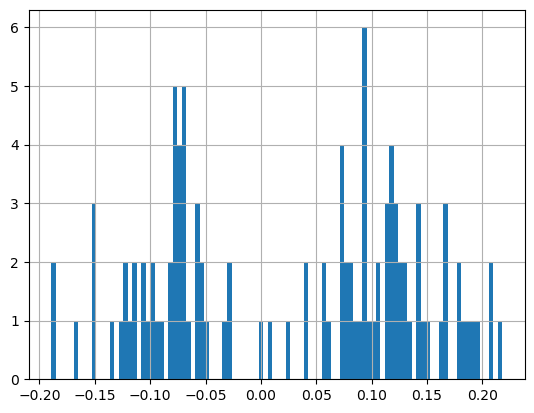

In [79]:
final_df.correlation.hist(bins=100)

In [80]:
# Clean up the names in the prev df
prev_df['feature_set'] = 'microbe'
prev_df['independent_feature'] = prev_df.apply(
    lambda row: extract_family_and_clean2(row['independent_feature'], row['feature_set']),
    axis=1
)

In [81]:
prev_df.sort_values(by='prevalence')

,independent_feature,prevalence,feature_set
6,Prevotellaceae_Prevotella_7,0.125255,microbe
19,Clostridia_NA_NA_NA,0.228727,microbe
25,Erysipelotrichaceae_Candidatus_Stoquefichus,0.259360,microbe
22,Methanobacteriaceae_Methanobrevibacter,0.275017,microbe
24,Chloroplast,0.300204,microbe
7,Lachnospiraceae_UC5_1_2E3,0.327434,microbe
36,Ruminococcaceae_Fournierella,0.333560,microbe
26,Lachnospiraceae_Coprococcus_2,0.385977,microbe
33,Ruminococcaceae_UCG_009,0.443839,microbe
31,Lachnospiraceae_Sellimonas,0.486726,microbe


In [82]:
final_df.shape

(107, 24)

In [83]:
# DROP CHLOROPLAST FROM FIGURE
final_df = final_df[~final_df.independent_feature.str.contains("Chloroplast", na=False)]

In [84]:
final_df.shape

(106, 24)

In [85]:
final_df.independent_feature.tolist()

['digestion_poor_or_lack_of_appetite',
 'digestion_bowel_movement_completion',
 'digestion_poor_or_lack_of_appetite',
 'digestion_poor_or_lack_of_appetite',
 'digestion_acid_reflux',
 'digestion_stress_eating',
 'digestion_acid_reflux',
 'digestion_nausea',
 'digestion_poor_or_lack_of_appetite',
 'digestion_stress_eating',
 'digestion_poor_or_lack_of_appetite',
 'digestion_supplements',
 'digestion_poor_or_lack_of_appetite',
 'lifestyle_alcohol_drinks_a_day_enum_daily',
 'mineral_mag_cal_zinc',
 'observed_features',
 'shannon_index',
 'berger_parker',
 'observed_features',
 'shannon_index',
 'berger_parker',
 'observed_features',
 'shannon_index',
 'berger_parker',
 'observed_features',
 'shannon_index',
 'berger_parker',
 'observed_features',
 'shannon_index',
 'berger_parker',
 'Lachnospiraceae_Lachnoclostridium',
 'Lachnospiraceae_Lachnoclostridium',
 'Lachnospiraceae_UC5_1_2E3',
 'Bacteroidaceae_Bacteroides',
 'Tannerellaceae_Parabacteroides',
 'Clostridiaceae_1_Clostridium_sensu_s

In [86]:
# Fix alcohol drinks a day 
final_df.replace("lifestyle_alcohol_drinks_a_day_enum_daily", "alcoholic_drinks_per_day", inplace=True)
final_df.replace("2-o-methylfucose (rare sugar in rhamnogalacturonan II)", "rare sugar in rhamnogalacturonan II", inplace=True)

In [87]:
final_df.rename(columns={'feature_set': 'source'}, inplace=True)

### Make false/empty rows for the dataframe so that the heatmap contains all 18 sleep y ticks

In [88]:
import pandas as pd

# All feature sets / panels
all_sources = final_df['source'].unique()

# Cartesian product
full_index = pd.MultiIndex.from_product(
    [features_dict['sleep_features_log1p_resids'], all_sources],
    names=['dependent_feature', 'source']
)

false_df = pd.DataFrame(index=full_index).reset_index()

final_df_padded = false_df.merge(final_df, on=['dependent_feature', 'source'], how='left')

final_df_padded['correlation'] = final_df_padded['correlation'].fillna(0)
final_df_padded['q_adjusted'] = final_df_padded['q_adjusted'].fillna(0.01)

# Now fill in the Na independent features
first_independent_by_source = (
    final_df
    .groupby('source')['independent_feature']
    .first()
)
final_df_padded['independent_feature'] = (
    final_df_padded['independent_feature']
    .fillna(
        final_df_padded['source'].map(first_independent_by_source)
    )
)

In [89]:
final_df_padded.source.unique()

array(['digestion_features', 'diet_daily_features', 'supplement_features',
       'diversity_features', 'new_microbe_features',
       'new_microbe_binarized_features', 'metabolite_features_log',
       'clinical_features_log1p', 'micom_features_log'], dtype=object)

In [90]:
# Now rename the sources so that they are nice for the plot.
sources_renamed = {
    'digestion_features': 'Digestion Questionnaire',
    'diet_daily_features': 'Daily Food Frequency Questionnaire',
    'supplement_features': 'Self-Reported Supplements',
    'diversity_features': 'Microbiome Alpha Diversity',
    'new_microbe_features': 'CLR-Transformed Microbe Abundances',
    'new_microbe_binarized_features': 'Microbe Presence/Absence',
    'metabolite_features_log': 'log(Untargeted Blood Metabolomics)',
    'clinical_features_log1p': 'log1p(Clinical Blood Chemistries)',
    'micom_features_log': 'log(MCMM Metabolic Outputs)'
}

final_df_padded['source'] = final_df_padded['source'].map(sources_renamed)

In [91]:
final_df_padded.dependent_feature.nunique()

18

In [92]:
final_df_padded.source.unique()

array(['Digestion Questionnaire', 'Daily Food Frequency Questionnaire',
       'Self-Reported Supplements', 'Microbiome Alpha Diversity',
       'CLR-Transformed Microbe Abundances', 'Microbe Presence/Absence',
       'log(Untargeted Blood Metabolomics)',
       'log1p(Clinical Blood Chemistries)', 'log(MCMM Metabolic Outputs)'],
      dtype=object)

In [93]:
sorted(final_df[final_df.source.str.contains('binarized')].independent_feature.unique())

['Christensenellaceae_R_7_group',
 'Clostridia_NA_NA_NA',
 'Clostridiales_Family_XIII_AD3011_group',
 'Clostridiales_vadinBB60_group',
 'Erysipelotrichaceae_Candidatus_Stoquefichus',
 'Lachnospiraceae_Coprococcus_1',
 'Lachnospiraceae_Coprococcus_2',
 'Lachnospiraceae_Coprococcus_3',
 'Lachnospiraceae_GCA_900066575',
 'Lachnospiraceae_UC5_1_2E3',
 'Methanobacteriaceae_Methanobrevibacter',
 'Peptostreptococcaceae_Romboutsia',
 'Prevotellaceae_Prevotella_7',
 'Ruminococcaceae_Fournierella',
 'Ruminococcaceae_NK4A214_group',
 'Ruminococcaceae_Oscillospira',
 'Ruminococcaceae_Ruminiclostridium_6',
 'Ruminococcaceae_Ruminococcus_1',
 'Ruminococcaceae_Ruminococcus_2',
 'Ruminococcaceae_UCG_002',
 'Ruminococcaceae_UCG_003',
 'Ruminococcaceae_UCG_009',
 'Ruminococcaceae_UCG_010',
 'Ruminococcaceae_UCG_014']

### Import the OHQ-defined perceived sleep quality scoring

In [2]:
sleep_happiness_scores = pd.read_csv('../activity_sleep_happiness_questionnaire_alignment_with_fitbit/fitbit_happiness_sleep_quality_scores_02-23-2026.csv')

In [95]:
sleep_happiness_scores.rename(columns={'beta_sign_sum': 'sleep_quality_sign'}, inplace=True)
sleep_happiness_scores['sleep_quality_sign'] = np.sign(sleep_happiness_scores['sleep_quality_sign'])

In [96]:
sleep_happiness_scores

,dependent_feature,sleep_quality_sign
0,bedtime_int_log1p_resid,-1.0
1,bedtime_int_std_log1p_resid,-1.0
2,sleep_awakeDuration_log1p_resid,-1.0
3,sleep_awakeDuration_std_log1p_resid,-1.0
4,sleep_awakeningsCount_log1p_resid,0.0
5,sleep_awakeningsCount_std_log1p_resid,-1.0
6,sleep_efficiency_log1p_resid,1.0
7,sleep_efficiency_std_log1p_resid,-1.0
8,sleep_minutesAfterWakeup_log1p_resid,-1.0
9,sleep_minutesAfterWakeup_std_log1p_resid,-1.0


### Keep this function, same as below except without the taxonomic assignments for the microbe features, so we can stitch it together in biorender

In [100]:
import altair as alt
import pandas as pd
import numpy as np


def plot_heatmap_by_feature_set(
    all_combined,
    label_map,
    sleep_duration_variables,
    sleep_duration_variability_variables,
    sleep_disruption_variables,
    sleep_disruption_variability_variables,
    sleep_efficiency_variables,
    sleep_efficiency_variability_variables,
    sleep_bedtime_variables,
    sleep_bedtime_variability_variables,
    source_order_map=None,
    title_text=None,
    # df with columns ['dependent_feature', 'sleep_quality_sign'] where sign can be either -1, 0, or 1
    sleep_quality_sign_df=None,
    score_row_label="Perceived Sleep Quality (summed)",
    # optional tweak knobs
    top_strip_height=10,
    top_strip_panel_height=18,
):

    # -----------------------------
    # Assign sleep groups
    # -----------------------------
    group_to_vars = {
        "Sleep Duration": sleep_duration_variables,
        "Sleep Duration Variability": sleep_duration_variability_variables,
        "Sleep Disruption": sleep_disruption_variables,
        "Sleep Disruption Variability": sleep_disruption_variability_variables,
        "Sleep Efficiency": sleep_efficiency_variables,
        "Sleep Efficiency Variability": sleep_efficiency_variability_variables,
        "Bedtime": sleep_bedtime_variables,
        "Bedtime Variability": sleep_bedtime_variability_variables,
    }
    group_map = {v: k for k, lst in group_to_vars.items() for v in lst}

    all_combined = all_combined.copy()
    all_combined["sleep_group"] = all_combined["dependent_feature"].map(group_map)

    # Apply label map
    all_combined["dependent_feature_clean"] = all_combined["dependent_feature"].map(label_map)
    all_combined["dependent_feature_clean"] = all_combined["dependent_feature_clean"].fillna(
        all_combined["dependent_feature"]
    )

    # Sort y-axis using the logical order
    sleep_order = [
        "Sleep Duration",
        "Sleep Duration Variability",
        "Sleep Disruption",
        "Sleep Disruption Variability",
        "Sleep Efficiency",
        "Sleep Efficiency Variability",
        "Bedtime",
        "Bedtime Variability"
    ]
    y_order = []
    for group in sleep_order:
        y_order.extend(
            [label_map.get(v, v) for v in group_to_vars[group] if v in all_combined["dependent_feature"].unique()]
        )

    # Color pallette for sleep groups
    group_color_map = {
        'Sleep Duration': '#1f78b4',                # blue
        'Sleep Duration Variability': '#a6cee3',    # light blue
        'Sleep Disruption': '#e31a1c',              # red
        'Sleep Disruption Variability': '#fb9a99',  # light red/pink
        'Bedtime': '#33a02c',                       # green
        'Bedtime Variability': '#b2df8a',           # light green (pairs with #33a02c)
        'Sleep Efficiency': '#6a3d9a',              # purple
        'Sleep Efficiency Variability': '#cab2d6'   # light purple
    }

    # Fitbit sleep group dataframe for y axis stripe
    stripe_df = pd.DataFrame(
        {
            "dependent_feature_clean": y_order,
            "sleep_group": [
                group
                for group in sleep_order
                for v in group_to_vars[group]
                if label_map.get(v, v) in y_order
            ],
        }
    )

    # -----------------------------
    # Sleep quality lookup: dependent_feature -> sign(-1/0/+1)
    # -----------------------------
    sleep_quality_lookup = {}
    has_sleep_quality = False
    if sleep_quality_sign_df is not None:
        needed = {"dependent_feature", "sleep_quality_sign"}
        missing = needed - set(sleep_quality_sign_df.columns)
        if missing:
            raise ValueError(f"sleep_quality_sign_df missing required columns: {sorted(missing)}")

        sleep_quality_lookup = dict(
            zip(
                sleep_quality_sign_df["dependent_feature"].astype(str),
                sleep_quality_sign_df["sleep_quality_sign"],
            )
        )
        has_sleep_quality = len(sleep_quality_lookup) > 0

    # -----------------------------
    # Source (aka feature set) ordering
    # -----------------------------
    if source_order_map is None:
        source_order_map = {}

    unique_sources = all_combined["source"].unique()

    # Keep microbe auto-ordering
    for src in ["CLR Transformed Microbe Abundances", "Microbe Presence/Absence"]:
        if src not in source_order_map:
            df_src = all_combined[all_combined["source"] == src].copy()
            if "original_feature_name" in df_src.columns:
                ordered = (
                    df_src.sort_values("original_feature_name")["independent_feature"]
                    .drop_duplicates()
                    .tolist()
                )
            else:
                ordered = df_src["independent_feature"].drop_duplicates().tolist()
            source_order_map[src] = ordered

    # Ensure x_order exists for EVERY source (fixes digestion/alpha alignment)
    for src in unique_sources:
        if src not in source_order_map:
            df_src = all_combined[all_combined["source"] == src].copy()
            if "original_feature_name" in df_src.columns:
                ordered = (
                    df_src.sort_values("original_feature_name")["independent_feature"]
                    .drop_duplicates()
                    .tolist()
                )
            else:
                ordered = df_src["independent_feature"].drop_duplicates().tolist()
            source_order_map[src] = ordered

    # -----------------------------
    # Precompute global max magnitude for top perceived sleep quality strip (comparable across panels)
    # score = sum_y( sign(beta) * sleep_quality_sign )
    # -----------------------------
    global_score_max = 1.0
    if has_sleep_quality:
        tmp = all_combined.copy()

        # map sleep quality sign (expects keys in original dependent_feature space)
        tmp["sleep_qsign"] = tmp["dependent_feature"].astype(str).map(sleep_quality_lookup)
        tmp["sleep_qsign"] = tmp["sleep_qsign"].apply(
            lambda v: 0 if pd.isna(v) else (1 if int(v) > 0 else (-1 if int(v) < 0 else 0))
        )

        # beta sign
        if "beta_sign" in tmp.columns:
            tmp["beta_sgn"] = tmp["beta_sign"]
        else:
            tmp["beta_sgn"] = np.sign(tmp["beta_adjusted"])

        tmp["beta_sgn"] = tmp["beta_sgn"].fillna(0).astype(float)
        tmp["beta_sgn"] = tmp["beta_sgn"].apply(lambda v: 1 if v > 0 else (-1 if v < 0 else 0))

        score_all = (
            tmp.assign(contrib=tmp["beta_sgn"] * tmp["sleep_qsign"])
            .groupby(["source", "independent_feature"], as_index=False)
            .agg(score=("contrib", "sum"))
        )

        if len(score_all) > 0:
            m = float(np.nanmax(np.abs(score_all["score"].values)))
            if np.isfinite(m) and m > 0:
                global_score_max = m

    # Correlation color scale (squares in the heatmap)
    corr_scale = alt.Scale(domain=[-0.25, 0.25], range=["#742881", "transparent", "#1B7939"])
    
    # Perceived sleep quality color scale (strip on top of plot)
    score_scale = alt.Scale(
        domain=[-global_score_max, 0.0, global_score_max],
        range=["#D75F4C", "transparent", "#3A93C3"]
    )

    # Plot the charts
    charts = []

    for i, source in enumerate(unique_sources):
        df_subset = all_combined[all_combined["source"] == source].copy()
        x_order = source_order_map.get(source, None)

        # Panel header
        header = (
            alt.Chart(pd.DataFrame({"label": [source]}))
            .mark_text(align="right", baseline="middle", fontWeight="bold", angle=270)
            .encode(text="label:N")
        ).encode(x=alt.value(-5), y=alt.value(369))

        # Heatmap
        base = (
            alt.Chart(df_subset)
            .mark_bar()
            .encode(
                x=alt.X(
                    "independent_feature:N",
                    title="",
                    sort=x_order,
                    axis=alt.Axis(
                        labelAngle=-90,
                        labelLimit=500,
                        grid=True,
                        gridColor="#e6e6e6",
                        gridWidth=0.6,
                    ),
                ),
                y=alt.Y(
                    "dependent_feature_clean:N",
                    sort=y_order,
                    title="log1p(Fitbit Sleep Features)" if i == 0 else None,
                    axis=alt.Axis(
                        labelAngle=225,
                        labelPadding=10,
                        labels=(i == 0),
                        ticks=False,
                        grid=True,
                        gridColor="#e6e6e6",
                        gridWidth=0.6,
                    ),
                ),
                color=alt.Color(
                    "correlation:Q",
                    scale=corr_scale,
                    legend=alt.Legend(title="Spearman r") if i == len(unique_sources) - 1 else None,
                ),
                tooltip=[
                    "independent_feature",
                    "dependent_feature_clean",
                    "beta_adjusted",
                    "correlation",
                    "q_adjusted",
                    "p_adjusted",
                ],
            )
        )

        # Sleep-group stripe ONLY on first panel
        if i == 0:
            stripe = (
                alt.Chart(stripe_df)
                .mark_rect(width=3)
                .encode(
                    x=alt.value(-1.5),
                    y=alt.Y(
                        "dependent_feature_clean:N",
                        sort=y_order,
                        axis=alt.Axis(labelPadding=0, titlePadding=0, domain=False)
                    ),
                    color=alt.Color(
                        "sleep_group:N",
                        scale=alt.Scale(
                            domain=list(group_color_map.keys()),
                            range=list(group_color_map.values()),
                        ),
                        legend=alt.Legend(title="Sleep Group") if i == len(unique_sources) - 1 else None,
                    ),
                )
            )
            main_panel = alt.layer(header, base, stripe)
        else:
            main_panel = alt.layer(header, base)

        # -----------------------------
        # TOP strip represents impact on perceived sleep quality
        # score = sum_y( sign(beta) * sleep_quality_sign )
        # -----------------------------
        if has_sleep_quality:
            df_sc = df_subset.copy()

            df_sc["sleep_qsign"] = df_sc["dependent_feature"].astype(str).map(sleep_quality_lookup)
            df_sc["sleep_qsign"] = df_sc["sleep_qsign"].apply(
                lambda v: 0 if pd.isna(v) else (1 if int(v) > 0 else (-1 if int(v) < 0 else 0))
            )

            if "beta_sign" in df_sc.columns:
                df_sc["beta_sgn"] = df_sc["beta_sign"]
            else:
                df_sc["beta_sgn"] = np.sign(df_sc["beta_adjusted"])

            df_sc["beta_sgn"] = df_sc["beta_sgn"].fillna(0).astype(float)
            df_sc["beta_sgn"] = df_sc["beta_sgn"].apply(lambda v: 1 if v > 0 else (-1 if v < 0 else 0))

            score_df = (
                df_sc.assign(contrib=df_sc["beta_sgn"] * df_sc["sleep_qsign"])
                .groupby("independent_feature", as_index=False)
                .agg(score=("contrib", "sum"))
            )

            # keep all x categories so strip aligns with heatmap width
            score_df = (
                score_df.set_index("independent_feature")
                .reindex(x_order)
                .fillna(0.0)
                .reset_index()
            )
            score_df["row"] = score_row_label

            top_strip = (
                alt.Chart(score_df)
                .mark_bar(height=top_strip_height)
                .encode(
                    x=alt.X(
                        "independent_feature:N",
                        sort=x_order,
                        axis=alt.Axis(labels=False, ticks=False, title=None),
                    ),
                    y=alt.Y("row:N", axis=None, title=None),
                    fill=alt.Fill(
                        "score:Q",
                        scale=score_scale,
                        legend=None
                    ),
                    tooltip=[
                        alt.Tooltip("independent_feature:N", title="Feature"),
                        alt.Tooltip("score:Q", title="Summed (+ better / - worse)"),
                    ],
                )
                .properties(height=top_strip_panel_height)
            )

            panel = alt.vconcat(top_strip, main_panel, spacing=0).resolve_scale(x="shared")
        else:
            panel = main_panel

        charts.append(panel)

    # Concat the different plots together
    final_chart = (
        alt.hconcat(*charts)
        .resolve_scale(y="shared", fill="independent")  # strip uses fill; heatmap uses color
        .configure_concat(spacing=5)
    )

    return final_chart, source_order_map

### Keep the function below, same as above, but adds in the taxonomic assignment color bar that we can copy/paste/fix in biorender

In [101]:
import altair as alt
import pandas as pd
import numpy as np


def plot_heatmap_by_feature_set(
    all_combined,
    label_map,
    sleep_duration_variables,
    sleep_duration_variability_variables,
    sleep_disruption_variables,
    sleep_disruption_variability_variables,
    sleep_efficiency_variables,
    sleep_efficiency_variability_variables,
    sleep_bedtime_variables,
    sleep_bedtime_variability_variables,
    source_order_map=None,
    title_text=None,
    # df with columns ['dependent_feature', 'sleep_quality_sign'] where sign can be -1, 0, or 1
    sleep_quality_sign_df=None,
    score_row_label="Perceived Sleep Quality (summed)",
    # optional tweak knobs
    top_strip_height=10,
    top_strip_panel_height=18,
    taxonomy_strip_height=4,
    taxonomy_strip_panel_height=3,
):

    # -----------------------------
    # Assign sleep groups
    # -----------------------------
    group_to_vars = {
        "Sleep Duration": sleep_duration_variables,
        "Sleep Duration Variability": sleep_duration_variability_variables,
        "Sleep Disruption": sleep_disruption_variables,
        "Sleep Disruption Variability": sleep_disruption_variability_variables,
        "Sleep Efficiency": sleep_efficiency_variables,
        "Sleep Efficiency Variability": sleep_efficiency_variability_variables,
        "Bedtime": sleep_bedtime_variables,
        "Bedtime Variability": sleep_bedtime_variability_variables,
    }
    group_map = {v: k for k, lst in group_to_vars.items() for v in lst}

    all_combined = all_combined.copy()
    all_combined["sleep_group"] = all_combined["dependent_feature"].map(group_map)

    # Apply label map
    all_combined["dependent_feature_clean"] = all_combined["dependent_feature"].map(label_map)
    all_combined["dependent_feature_clean"] = all_combined["dependent_feature_clean"].fillna(
        all_combined["dependent_feature"]
    )

    # -----------------------------
    # Use class_tax from input (all_combined) df
    # -----------------------------
    if "class_tax" not in all_combined.columns:
        all_combined["class_tax"] = np.nan

    # keep missing values allowed, but assign Unknown for plotting strip/legend
    all_combined["class_tax_plot"] = all_combined["class_tax"].astype("object")
    all_combined["class_tax_plot"] = all_combined["class_tax_plot"].where(
        pd.notna(all_combined["class_tax_plot"]), "Unknown"
    )
    all_combined["class_tax_plot"] = all_combined["class_tax_plot"].astype(str)

    # -----------------------------
    # Define y-axis order
    # -----------------------------
    sleep_order = [
        "Sleep Duration",
        "Sleep Duration Variability",
        "Sleep Disruption",
        "Sleep Disruption Variability",
        "Sleep Efficiency",
        "Sleep Efficiency Variability",
        "Bedtime",
        "Bedtime Variability"
    ]

    y_order = []
    for group in sleep_order:
        y_order.extend(
            [label_map.get(v, v) for v in group_to_vars[group] if v in all_combined["dependent_feature"].unique()]
        )

    group_color_map = {
        "Sleep Duration": "#1f78b4",
        "Sleep Duration Variability": "#a6cee3",
        "Sleep Disruption": "#e31a1c",
        "Sleep Disruption Variability": "#fb9a99",
        "Bedtime": "#33a02c",
        "Bedtime Variability": "#b2df8a",
        "Sleep Efficiency": "#6a3d9a",
        "Sleep Efficiency Variability": "#cab2d6",
    }

    stripe_df = pd.DataFrame(
        {
            "dependent_feature_clean": y_order,
            "sleep_group": [
                group
                for group in sleep_order
                for v in group_to_vars[group]
                if label_map.get(v, v) in y_order
            ],
        }
    )

    # -----------------------------
    # Sleep quality lookup
    # -----------------------------
    sleep_quality_lookup = {}
    has_sleep_quality = False
    if sleep_quality_sign_df is not None:
        needed = {"dependent_feature", "sleep_quality_sign"}
        missing = needed - set(sleep_quality_sign_df.columns)
        if missing:
            raise ValueError(f"sleep_quality_sign_df missing required columns: {sorted(missing)}")

        sleep_quality_lookup = dict(
            zip(
                sleep_quality_sign_df["dependent_feature"].astype(str),
                sleep_quality_sign_df["sleep_quality_sign"],
            )
        )
        has_sleep_quality = len(sleep_quality_lookup) > 0

    # -----------------------------
    # Source (feature set) ordering
    # -----------------------------
    if source_order_map is None:
        source_order_map = {}

    unique_sources = all_combined["source"].unique()

    # auto-fill ordering for any sources not manually specified
    for src in unique_sources:
        if src not in source_order_map:
            df_src = all_combined[all_combined["source"] == src].copy()
            if "original_feature_name" in df_src.columns:
                ordered = (
                    df_src.sort_values("original_feature_name")["independent_feature"]
                    .drop_duplicates()
                    .tolist()
                )
            else:
                ordered = df_src["independent_feature"].drop_duplicates().tolist()
            source_order_map[src] = ordered

    # -----------------------------
    # Global max magnitude for top perceived sleep quality strip
    # -----------------------------
    global_score_max = 1.0
    if has_sleep_quality:
        tmp = all_combined.copy()

        tmp["sleep_qsign"] = tmp["dependent_feature"].astype(str).map(sleep_quality_lookup)
        tmp["sleep_qsign"] = tmp["sleep_qsign"].apply(
            lambda v: 0 if pd.isna(v) else (1 if int(v) > 0 else (-1 if int(v) < 0 else 0))
        )

        if "beta_sign" in tmp.columns:
            tmp["beta_sgn"] = tmp["beta_sign"]
        else:
            tmp["beta_sgn"] = np.sign(tmp["beta_adjusted"])

        tmp["beta_sgn"] = tmp["beta_sgn"].fillna(0).astype(float)
        tmp["beta_sgn"] = tmp["beta_sgn"].apply(lambda v: 1 if v > 0 else (-1 if v < 0 else 0))

        score_all = (
            tmp.assign(contrib=tmp["beta_sgn"] * tmp["sleep_qsign"])
            .groupby(["source", "independent_feature"], as_index=False)
            .agg(score=("contrib", "sum"))
        )

        if len(score_all) > 0:
            m = float(np.nanmax(np.abs(score_all["score"].values)))
            if np.isfinite(m) and m > 0:
                global_score_max = m

    corr_scale = alt.Scale(domain=[-0.25, 0.25], range=["#742881", "transparent", "#1B7939"])
    score_scale = alt.Scale(
        domain=[-global_score_max, 0.0, global_score_max],
        range=["#D75F4C", "transparent", "#3A93C3"]
    )

    # -----------------------------
    # Class taxonomy legend and color pallette
    # -----------------------------
    all_classes = (
        all_combined["class_tax_plot"]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    class_palette = alt.Scale(
        domain=all_classes,
        range=[
            "#66C2A5",
            "#FC8D62",
            "#8C510A",  # deep green 
            "#E7298A",  # magenta 
            "#A6D854",
        ] * max(1, int(np.ceil(len(all_classes) / 5)))
    )

    
    # Plot the charts
    charts = []

    for i, source in enumerate(unique_sources):
        df_subset = all_combined[all_combined["source"] == source].copy()

        x_order = source_order_map.get(source, None)
        if x_order is not None:
            x_order = list(dict.fromkeys(x_order))

        # -----------------------------
        # Panel header
        # -----------------------------
        header = (
            alt.Chart(pd.DataFrame({"label": [source]}))
            .mark_text(align="right", baseline="middle", fontWeight="bold", angle=270)
            .encode(text="label:N")
        ).encode(x=alt.value(-5), y=alt.value(369))

        # -----------------------------
        # Heatmap
        # -----------------------------
        base = (
            alt.Chart(df_subset)
            .mark_bar()
            .encode(
                x=alt.X(
                    "independent_feature:N",
                    title="",
                    sort=x_order,
                    axis=alt.Axis(
                        labelAngle=-90,
                        labelLimit=500,
                        labels=False,
                        ticks=False,
                        domain=False,
                        grid=True,
                        gridColor="#e6e6e6",
                        gridWidth=0.6,
                    ),
                ),
                y=alt.Y(
                    "dependent_feature_clean:N",
                    sort=y_order,
                    title="log1p(Fitbit Sleep Features)" if i == 0 else None,
                    axis=alt.Axis(
                        labelAngle=225,
                        labelPadding=10,
                        labels=(i == 0),
                        ticks=False,
                        grid=True,
                        gridColor="#e6e6e6",
                        gridWidth=0.6,
                    ),
                ),
                color=alt.Color(
                    "correlation:Q",
                    scale=corr_scale,
                    legend=alt.Legend(title="Spearman r") if i == len(unique_sources) - 1 else None,
                ),
                tooltip=[
                    "independent_feature",
                    "dependent_feature_clean",
                    "beta_adjusted",
                    "correlation",
                    "q_adjusted",
                    "p_adjusted",
                    alt.Tooltip("class_tax_plot:N", title="Class taxonomy"),
                ],
            )
        )

        # -----------------------------
        # Sleep-group stripe on first panel
        # -----------------------------
        if i == 0:
            stripe = (
                alt.Chart(stripe_df)
                .mark_rect(width=3)
                .encode(
                    x=alt.value(-1.5),
                    y=alt.Y(
                        "dependent_feature_clean:N",
                        sort=y_order,
                        axis=alt.Axis(labelPadding=0, titlePadding=0, domain=False)
                    ),
                    color=alt.Color(
                        "sleep_group:N",
                        scale=alt.Scale(
                            domain=list(group_color_map.keys()),
                            range=list(group_color_map.values()),
                        ),
                        legend=alt.Legend(title="Sleep Group") if i == len(unique_sources) - 1 else None,
                    ),
                )
            )
            main_panel = alt.layer(header, base, stripe)
        else:
            main_panel = alt.layer(header, base)

        # -----------------------------
        # Build perceived sleep quality top strip
        # -----------------------------
        top_strip = None
        if has_sleep_quality:
            df_sc = df_subset.copy()

            df_sc["sleep_qsign"] = df_sc["dependent_feature"].astype(str).map(sleep_quality_lookup)
            df_sc["sleep_qsign"] = df_sc["sleep_qsign"].apply(
                lambda v: 0 if pd.isna(v) else (1 if int(v) > 0 else (-1 if int(v) < 0 else 0))
            )

            if "beta_sign" in df_sc.columns:
                df_sc["beta_sgn"] = df_sc["beta_sign"]
            else:
                df_sc["beta_sgn"] = np.sign(df_sc["beta_adjusted"])

            df_sc["beta_sgn"] = df_sc["beta_sgn"].fillna(0).astype(float)
            df_sc["beta_sgn"] = df_sc["beta_sgn"].apply(lambda v: 1 if v > 0 else (-1 if v < 0 else 0))

            score_df = (
                df_sc.assign(contrib=df_sc["beta_sgn"] * df_sc["sleep_qsign"])
                .groupby("independent_feature", as_index=False)
                .agg(score=("contrib", "sum"))
            )

            if x_order is not None:
                score_df = (
                    score_df.set_index("independent_feature")
                    .reindex(x_order)
                    .fillna(0.0)
                    .reset_index()
                )

            score_df["row"] = score_row_label

            top_strip = (
                alt.Chart(score_df)
                .mark_bar(height=top_strip_height)
                .encode(
                    x=alt.X(
                        "independent_feature:N",
                        sort=x_order,
                        axis=alt.Axis(labels=False, ticks=False, domain=False, title=None),
                    ),
                    y=alt.Y("row:N", axis=None, title=None),
                    fill=alt.Fill(
                        "score:Q",
                        scale=score_scale,
                        legend=None,
                    ),
                    tooltip=[
                        alt.Tooltip("independent_feature:N", title="Feature"),
                        alt.Tooltip("score:Q", title="Summed (+ better / - worse)"),
                    ],
                )
                .properties(height=top_strip_panel_height)
            )

        # -----------------------------
        # Build bottom class taxonomy strip
        # -----------------------------
        taxonomy_strip = (
            df_subset[["independent_feature", "class_tax_plot"]]
            .dropna(subset=["independent_feature"])
            .groupby("independent_feature", as_index=False)["class_tax_plot"]
            .first()
        )

        if x_order is not None:
            taxonomy_strip = (
                taxonomy_strip.set_index("independent_feature")
                .reindex(x_order)
                .reset_index()
            )

        taxonomy_strip["row"] = "taxonomy"
        taxonomy_strip["class_tax_plot"] = taxonomy_strip["class_tax_plot"].fillna("Unknown")

        taxonomy_strip_chart = (
            alt.Chart(taxonomy_strip)
            .mark_rect(height=taxonomy_strip_height)
            .encode(
                x=alt.X(
                    "independent_feature:N",
                    sort=x_order,
                    axis=alt.Axis(
                        labelAngle=-90,
                        labelLimit=500,
                        ticks=False,
                        domain=False,
                        title=None,
                        labelPadding=2,
                    ),
                ),
                y=alt.Y("row:N", axis=None, title=None),
                fill=alt.Fill(
                    "class_tax_plot:N",
                    scale=class_palette,
                    legend=alt.Legend(title="Microbe Class") if i == len(unique_sources) - 1 else None,
                ),
                tooltip=[
                    alt.Tooltip("independent_feature:N", title="Feature"),
                    alt.Tooltip("class_tax_plot:N", title="Microbe Class"),
                ],
            )
            .properties(height=taxonomy_strip_panel_height)
        )

        # -----------------------------
        # Combine the charts/panels
        # -----------------------------
        panel_parts = []
        if top_strip is not None:
            panel_parts.append(top_strip)
        panel_parts.append(main_panel)
        panel_parts.append(taxonomy_strip_chart)

        if len(panel_parts) == 1:
            panel = panel_parts[0]
        else:
            panel = alt.vconcat(*panel_parts, spacing=0).resolve_scale(x="shared")

        charts.append(panel)

    # -----------------------------
    # Final chart
    # -----------------------------
    final_chart = (
        alt.hconcat(*charts)
        .resolve_scale(y="shared", fill="independent")
        .configure_concat(spacing=5)
    )

    if title_text is not None:
        final_chart = final_chart.properties(title=title_text)

    return final_chart, source_order_map

In [102]:
source_order_map = {
    'log1p(Clinical Blood Chemistries)': ['omega_6_omega_3_ratio', 'omega_3_index', 'dha', 'epa', 'insulin'],
    'log(Untargeted Blood Metabolomics)': ['cortisol', 'X - 12816', 'docosahexaenoylcarnitine (C22:6)'],
    'log(MCMM Metabolic Outputs)': [
        # Sugars and rare sugars (mostly plant-derived RG-II components)
        'D-Fructose',
        'rare sugar in rhamnogalacturonan II',

        # Amino acids and derivatives
        'L-proline',
        'L-threonine',
        '2-Oxobutanoate',
        
        # Protein/mucin-related metabolites
        'protein-linked serine or threonine residue (O-glycosylation site)',

        # Bile acids
        '7-Dehydrochenodeoxycholate',

        # Microbial / lipid metabolism intermediates
        'laurate',

        # Vitamins, nucleosides, osmolytes
        'Pyridoxine',
        'Guanosine',
        'Taurine'
        ],

    'CLR-Transformed Microbe Abundances': sorted(final_df_padded[final_df_padded.source.str.contains('CLR')].independent_feature.unique()),
    'Microbe Presence/Absence': sorted(final_df_padded[final_df_padded.source.str.contains('Presence/Absence')].independent_feature.unique())
}

plot, source_order_map = plot_heatmap_by_feature_set(
    all_combined=final_df_padded,
    label_map=label_map,
    sleep_duration_variables=sleep_duration_variables,
    sleep_duration_variability_variables=sleep_duration_variability_variables,
    sleep_disruption_variables=sleep_disruption_variables,
    sleep_disruption_variability_variables=sleep_disruption_variability_variables,
    sleep_efficiency_variables=sleep_efficiency_variables,
    sleep_efficiency_variability_variables=sleep_efficiency_variability_variables,
    sleep_bedtime_variables=sleep_bedtime_variables,
    sleep_bedtime_variability_variables=sleep_bedtime_variability_variables,
    sleep_quality_sign_df=sleep_happiness_scores,
    source_order_map=source_order_map
)

In [103]:
plot

alt.HConcatChart(...)

## Make a Sankey diagram that includes a total omics level impact on perceived sleep quality as well as class taxonomic assignment for microbes

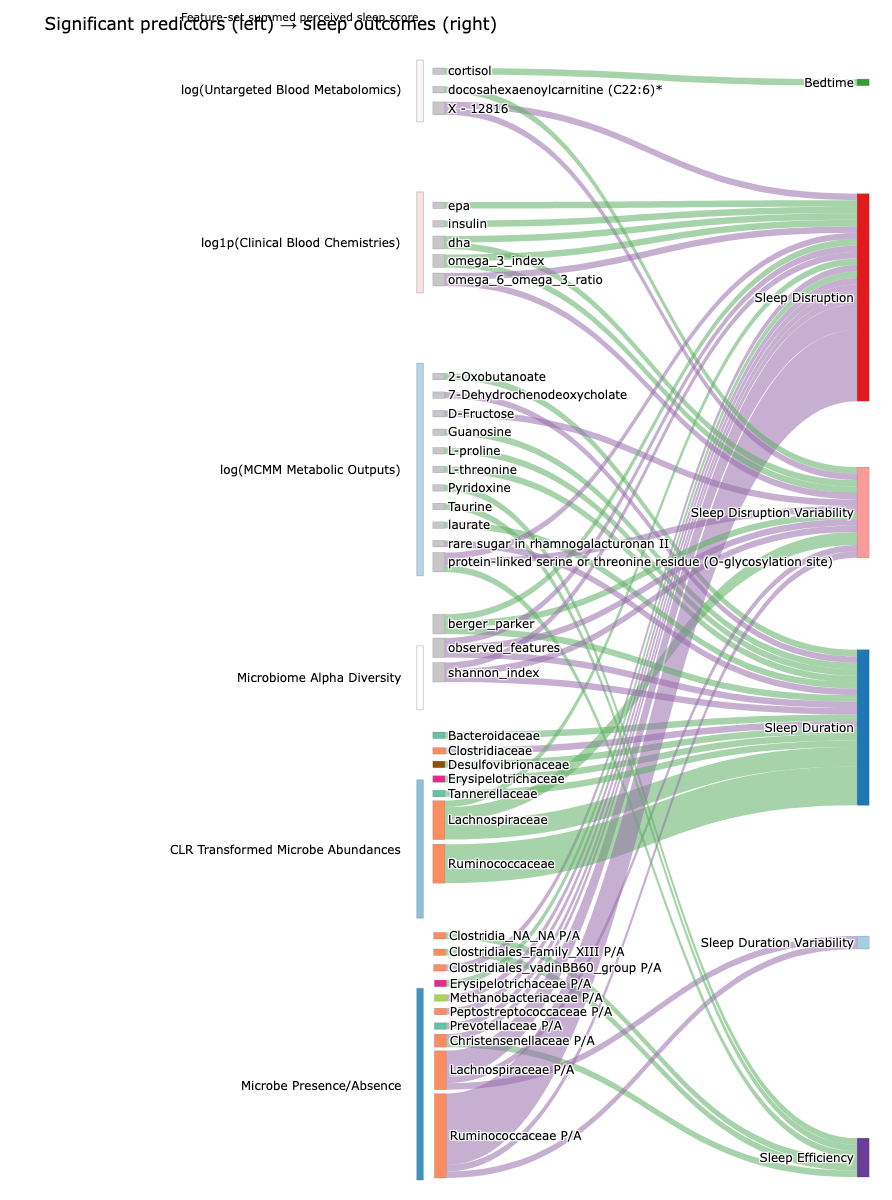

Class color map:
             tax_class    color
0          Bacteroidia  #66C2A5
1           Clostridia  #FC8D62
2  Deltaproteobacteria  #8C510A
3     Erysipelotrichia  #E7298A
4      Methanobacteria  #A6D854
5          Non-microbe  #66C2A5


In [129]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.colors as mcolors
from itertools import cycle, islice

MICROBIOME_FEATURE_SETS = {
    "new_microbe_features",
    "new_microbe_binarized_features",
    "micom_features_log",
    "diversity_features",
}

FEATURE_SET_ORDER = [
    "metabolite_features_log",
    "clinical_features_log1p",
    "micom_features_log",
    "diversity_features",
    "new_microbe_features",
    "new_microbe_binarized_features",
]

FEATURE_SET_COLORS = {
    "new_microbe_features": "#8A8A8A",
    "new_microbe_binarized_features": "#8A8A8A",
    "micom_features_log": "#8A8A8A",
    "diversity_features": "#8A8A8A",
    "metabolite_features_log": "#8A8A8A",
    "proteomics_features": "#8A8A8A",
    "clinical_features_log1p": "#8A8A8A",
    "sleep": "#0F0F0F",
    "other": "#8A8A8A",
}

SLEEP_NODE_COLORS = {
    "Sleep Duration": "#1f78b4",
    "Sleep Duration Variability": "#a6cee3",
    "Sleep Disruption": "#e31a1c",
    "Sleep Disruption Variability": "#fb9a99",
    "Bedtime": "#33a02c",
    "Sleep Efficiency": "#6a3d9a",
}

FEATURE_SET_LABELS = {
    "diet_daily_features": "Daily Food Frequency Questionnaire",
    "supplement_features": "Self-Reported Supplements",
    "digestion_features": "Digestion Questionnaire",
    "proteomics_features": "Blood Proteomics",
    "metabolite_features_log": "log(Untargeted Blood Metabolomics)",
    "clinical_features_log1p": "log1p(Clinical Blood Chemistries)",
    "diversity_features": "Microbiome Alpha Diversity",
    "new_microbe_features": "CLR Transformed Microbe Abundances",
    "new_microbe_binarized_features": "Microbe Presence/Absence",
    "micom_features_log": "log(MCMM Metabolic Outputs)",
}

POS_COLOR = "rgba(92,174,99,0.55)"
NEG_COLOR = "rgba(152,110,172,0.55)"

# -----------------------------
# Layout tuning knobs
# -----------------------------
TEXT_X = -0.06
BAR_X0 = -0.03
BAR_X1 = -0.015
LEGEND_NOTE_X = -0.02

# -----------------------------
# Class palette for microbe nodes
# -----------------------------
CLASS_PALETTE = [
    "#66C2A5",
    "#FC8D62",
    "#8C510A",
    "#E7298A",
    "#A6D854",
]

def get_node_color(feature_set: str) -> str:
    return FEATURE_SET_COLORS.get(feature_set, FEATURE_SET_COLORS["other"])


# -----------------------------
# Label cleaning
# -----------------------------
def summarize_predictor(feature, feature_set):
    if not isinstance(feature, str):
        return feature

    if "microbe" in feature_set:
        parts = feature.split("_")

        if "Family_XIII" in feature:
            label = f"{parts[3]}_Family_XIII"
        elif "Clostridia_nan_nan_nan" in feature:
            label = f"{parts[2]}_NA_NA"
        elif "Clostridiales_vadinBB60_group" in feature:
            label = "Clostridiales_vadinBB60_group"
        else:
            label = parts[4] if len(parts) > 4 else feature

        if feature.endswith("binarized"):
            label += " P/A"

        return label

    if "clinical" in feature_set and feature.endswith("_log1p"):
        return feature[:-6]

    return feature


# -----------------------------
# Extract taxonomic class from ORIGINAL microbe strings
# Assumes class is the 3rd token: Kingdom_Phylum_Class_Order_Family...
# Family comes after class, so multiple families can share a class.
# -----------------------------
def extract_taxonomic_class(feature, feature_set):
    if not isinstance(feature, str):
        return "Unknown"

    if "microbe" in feature_set:
        parts = feature.split("_")
        if len(parts) >= 3:
            return parts[2]
        return "Unknown"

    return "Non-microbe"


# -----------------------------
# Helper: grouped y positions
# -----------------------------
def grouped_y_positions(grouped_df, gap=0.07, y_min=0.01, y_max=0.99):
    ordered_groups = [g for g in FEATURE_SET_ORDER if g in grouped_df["feature_set"].values]

    total_nodes = len(grouped_df)
    n_gaps = max(len(ordered_groups) - 1, 0)

    usable_height = (y_max - y_min) - gap * n_gaps
    step = usable_height / max(total_nodes - 1, 1) if total_nodes > 1 else 0

    y_lookup = {}
    group_midpoints = {}
    current_y = y_min

    for g in ordered_groups:
        members = grouped_df.loc[
            grouped_df["feature_set"] == g,
            "independent_feature_summarized"
        ].tolist()

        ys = []
        for m in members:
            y_lookup[m] = current_y
            ys.append(current_y)
            current_y += step

        if ys:
            group_midpoints[g] = float(np.mean(ys))

        current_y += gap

    return y_lookup, group_midpoints


# -----------------------------
# Helper: score -> color
# -----------------------------
def score_to_color(score, max_abs_score):
    """
    Negative -> red, zero -> white, positive -> blue
    """
    t = score / max_abs_score if max_abs_score > 0 else 0
    t = max(-1, min(1, t))

    neg = np.array(mcolors.to_rgb("#D75F4C"))
    mid = np.array(mcolors.to_rgb("#FFFFFF"))
    pos = np.array(mcolors.to_rgb("#3A93C3"))

    if t < 0:
        w = abs(t)
        rgb = mid * (1 - w) + neg * w
    else:
        w = t
        rgb = mid * (1 - w) + pos * w

    return mcolors.to_hex(rgb)


# -----------------------------
# MAIN
# Requires:
#   combined_df
#   sleep_happiness_scores with columns:
#       - dependent_feature
#       - sleep_quality_sign in {-1,0,1}
# -----------------------------

# -----------------------------
# Prepare data
# -----------------------------
df = combined_df[(combined_df["shared_hit"] == 1)].copy()

df = df.replace(
    "2-o-methylfucose (rare sugar in rhamnogalacturonan II)",
    "rare sugar in rhamnogalacturonan II"
)

df = df[~df["feature_set"].str.contains("digestion|diet|supplement", na=False)].copy()
df = df.loc[~df["independent_feature"].str.contains("Chloroplast", na=False)].copy()

df["independent_feature_summarized"] = df.apply(
    lambda r: summarize_predictor(r["independent_feature"], r["feature_set"]),
    axis=1
)

# -----------------------------
# Assign taxonomic class from ORIGINAL microbe feature strings
# -----------------------------
df["tax_class"] = df.apply(
    lambda r: extract_taxonomic_class(r["independent_feature"], r["feature_set"]),
    axis=1
)

# -----------------------------
# Count unique taxa per summarized microbiome node
# -----------------------------
microbe_counts = (
    df.loc[df["feature_set"].isin(MICROBIOME_FEATURE_SETS)]
      .groupby(["feature_set", "sleep_group", "independent_feature_summarized"])["independent_feature"]
      .nunique()
      .rename("raw_microbe_count")
      .reset_index()
)

df = df.merge(
    microbe_counts,
    on=["feature_set", "sleep_group", "independent_feature_summarized"],
    how="left"
)

# -----------------------------
# Aggregate edges
# All links same weight except collapsed family taxa nodes
# -----------------------------
agg = (
    df.groupby(["independent_feature_summarized", "sleep_group", "feature_set"], as_index=False)
      .agg(
          beta=("beta_adjusted", "mean"),
          raw_microbe_count=("raw_microbe_count", "max"),
      )
)

agg["value"] = 1.0

# Only thicken collapsed family-level microbiome nodes
mask = (
    agg["feature_set"].isin(MICROBIOME_FEATURE_SETS)
    & agg["raw_microbe_count"].fillna(1).gt(1)
)

agg.loc[mask, "value"] = agg.loc[mask, "raw_microbe_count"].astype(float)
agg["link_color"] = np.where(agg["beta"] > 0, POS_COLOR, NEG_COLOR)

# -----------------------------
# Compute perceived sleep score per feature_set
# score = sum(sign(beta_adjusted) * sleep_quality_sign)
# -----------------------------
sleep_quality_lookup = dict(
    zip(
        sleep_happiness_scores["dependent_feature"].astype(str),
        sleep_happiness_scores["sleep_quality_sign"],
    )
)

score_df = df.copy()

score_df["sleep_qsign"] = score_df["dependent_feature"].astype(str).map(sleep_quality_lookup)
score_df["sleep_qsign"] = score_df["sleep_qsign"].apply(
    lambda v: 0 if pd.isna(v) else (1 if int(v) > 0 else (-1 if int(v) < 0 else 0))
)

score_df["beta_sgn"] = np.sign(score_df["beta_adjusted"]).fillna(0).astype(float)
score_df["beta_sgn"] = score_df["beta_sgn"].apply(lambda v: 1 if v > 0 else (-1 if v < 0 else 0))

feature_set_score_df = (
    score_df.assign(contrib=score_df["beta_sgn"] * score_df["sleep_qsign"])
    .groupby("feature_set", as_index=False)
    .agg(score=("contrib", "sum"))
)

global_score_max = max(float(feature_set_score_df["score"].abs().max()), 1.0)

feature_set_score_lookup = dict(
    zip(feature_set_score_df["feature_set"], feature_set_score_df["score"])
)

# -----------------------------
# Order predictors by total edge weight
# -----------------------------
predictor_weights = (
    agg.groupby(["independent_feature_summarized", "feature_set"], as_index=False)["value"]
       .sum()
       .rename(columns={"value": "total_value"})
)

predictor_weights["feature_set_rank"] = predictor_weights["feature_set"].map(
    {fs: i for i, fs in enumerate(FEATURE_SET_ORDER)}
).fillna(len(FEATURE_SET_ORDER))

predictor_df = predictor_weights.sort_values(
    ["feature_set_rank", "total_value"],
    ascending=[True, True]
).reset_index(drop=True)

predictors = predictor_df["independent_feature_summarized"].tolist()
sleep_groups = sorted(agg["sleep_group"].dropna().unique().tolist())

all_nodes = predictors + sleep_groups
node_index = {n: i for i, n in enumerate(all_nodes)}

# -----------------------------
# Assign dominant class to each summarized predictor node
# Uses ORIGINAL microbe rows that collapsed into that summarized node.
# Non-microbe nodes are left gray later.
# -----------------------------
predictor_class_df = (
    df.loc[df["feature_set"].isin(MICROBIOME_FEATURE_SETS)]
      .groupby(["independent_feature_summarized", "feature_set"])["tax_class"]
      .agg(lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown")
      .reset_index(name="tax_class")
)

predictor_df = predictor_df.merge(
    predictor_class_df,
    on=["independent_feature_summarized", "feature_set"],
    how="left"
)

all_classes = (
    predictor_df.loc[predictor_df["feature_set"].isin(MICROBIOME_FEATURE_SETS), "tax_class"]
    .fillna("Unknown")
    .astype(str)
    .drop_duplicates()
    .sort_values()
    .tolist()
)

# cycle palette if there are more classes than colors provided
class_colors = list(islice(cycle(CLASS_PALETTE), len(all_classes)))
class_color_map = dict(zip(all_classes, class_colors))

# -----------------------------
# Node positioning
# -----------------------------
predictor_y_lookup, group_midpoints = grouped_y_positions(
    predictor_df,
    gap=0.07,
    y_min=0.01,
    y_max=0.99,
)

sleep_y = np.linspace(0.02, 0.98, len(sleep_groups)).tolist()

x = [0.02] * len(predictors) + [0.98] * len(sleep_groups)
y = [predictor_y_lookup[p] for p in predictors] + sleep_y

# -----------------------------
# Links
# -----------------------------
sources = agg["independent_feature_summarized"].map(node_index).tolist()
targets = agg["sleep_group"].map(node_index).tolist()
values = agg["value"].tolist()
link_colors = agg["link_color"].tolist()

# -----------------------------
# Node colors
# Microbiome nodes colored by taxonomic class.
# Non-microbe nodes stay gray.
# -----------------------------
predictor_to_feature_set = dict(
    zip(predictor_df["independent_feature_summarized"], predictor_df["feature_set"])
)

predictor_to_class = dict(
    zip(predictor_df["independent_feature_summarized"], predictor_df["tax_class"])
)

CLASS_COLORED_FEATURE_SETS = {
    "new_microbe_features",
    "new_microbe_binarized_features",
}

node_colors = []

for n in all_nodes:
    if n in sleep_groups:
        node_colors.append(SLEEP_NODE_COLORS.get(n, "#444444"))

    else:
        fs = predictor_to_feature_set[n]

        # ONLY color these two feature sets by class
        if fs in CLASS_COLORED_FEATURE_SETS:
            cls = predictor_to_class.get(n, "Unknown")
            node_colors.append(class_color_map.get(cls, "#C7C7C7"))

        # EVERYTHING else stays gray (including MCMM, diversity, etc.)
        else:
            node_colors.append("#C7C7C7")

# -----------------------------
# Hover text
# -----------------------------
link_hover = (
    "Predictor: " + agg["independent_feature_summarized"].astype(str)
    + "<br>Sleep: " + agg["sleep_group"].astype(str)
    + "<br>β (mean): " + agg["beta"].round(3).astype(str)
    + "<br>Flow value: " + agg["value"].round(2).astype(str)
)

# -----------------------------
# Plot
# -----------------------------
fig = go.Figure(
    go.Sankey(
        arrangement="freeform",  # lets you drag nodes in the browser
        node=dict(
            pad=16,
            thickness=12,
            line=dict(color="rgba(0,0,0,0.25)", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=x,
            y=y,
            hovertemplate="%{label}<extra></extra>",
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            hovertemplate=link_hover + "<extra></extra>",
        ),
        textfont=dict(color="black", size=12),
    )
)

# -----------------------------
# Left-side feature-set labels + colored bars
# -----------------------------
annotations = []
shapes = []

for fs, ymid in group_midpoints.items():
    annotations.append(
        dict(
            x=TEXT_X,
            y=1 - ymid,
            xref="paper",
            yref="paper",
            text=FEATURE_SET_LABELS.get(fs, fs),
            showarrow=False,
            xanchor="right",
            yanchor="middle",
            font=dict(size=12, color="black"),
        )
    )

    members = predictor_df.loc[
        predictor_df["feature_set"] == fs,
        "independent_feature_summarized"
    ].tolist()

    if len(members) == 0:
        continue

    ys = [predictor_y_lookup[m] for m in members]
    y0 = 1 - max(ys)
    y1 = 1 - min(ys)

    # small padding so the bar spans the full grouped block
    pad = 0.012
    y0 = max(0, y0 - pad)
    y1 = min(1, y1 + pad)

    score = feature_set_score_lookup.get(fs, 0)
    bar_color = score_to_color(score, global_score_max)

    shapes.append(
        dict(
            type="rect",
            xref="paper",
            yref="paper",
            x0=BAR_X0,
            x1=BAR_X1,
            y0=y0,
            y1=y1,
            line=dict(color="rgba(120,120,120,0.6)", width=0.6),
            fillcolor=bar_color,
            layer="below",
        )
    )

# optional legend note for the bars
annotations.append(
    dict(
        x=LEGEND_NOTE_X,
        y=1.03,
        xref="paper",
        yref="paper",
        text="Feature-set summed perceived sleep score",
        showarrow=False,
        xanchor="right",
        yanchor="bottom",
        font=dict(size=11, color="black"),
    )
)

fig.update_layout(
    title="Significant predictors (left) → sleep outcomes (right)",
    width=1000,
    height=1200,
    margin=dict(l=430, r=20, t=60, b=20),
    annotations=annotations,
    shapes=shapes,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(size=12, color="black"),  # all layout text black
)

fig.show()

# Optional: inspect the class -> color mapping
print("Class color map:")
print(pd.DataFrame({"tax_class": all_classes, "color": class_colors}))

## Make a separate plot of the figure legends that are the same domains as what's plotted above that can be pasted together with the figures in Biorender

In [83]:
import altair as alt
import pandas as pd


def make_legends_only_chart(
    corr_domain=(-0.25, 0, 0.25),
    corr_range=("#742881", "transparent", "#1B7939"),
    sleep_group_color_map=None,
    score_max=5,
):
    """
    Legend-only chart:
      1) Spearman r (color)
      2) Sleep Group (color)
      3) Perceived Sleep Quality (summed) (fill) with labels:
         top=Better, middle=Neutral, bottom=Worse
    """
    if sleep_group_color_map is None:
        sleep_group_color_map = {
            "Sleep Duration": "#1f78b4",
            "Sleep Duration Variability": "#a6cee3",
            "Sleep Disruption": "#e31a1c",
            "Sleep Disruption Variability": "#fb9a99",
            "Bedtime": "#33a02c",
            "Bedtime Variability": "#b2df8a",
            "Sleep Efficiency": "#6a3d9a",
            "Sleep Efficiency Variability": "#cab2d6",
        }

    corr_scale = alt.Scale(domain=list(corr_domain), range=list(corr_range))

    # IMPORTANT: ordered domain so legend is (top) Better -> Neutral -> Worse (bottom)
    score_scale = alt.Scale(
        domain=[-1, 0, 1],
        range=["#D75F4C", "transparent", "#3A93C3"],
    )

    # 1) Spearman r legend
    spearman_df = pd.DataFrame({"correlation": [corr_domain[0], corr_domain[1], corr_domain[2]]})
    spearman_legend = (
        alt.Chart(spearman_df)
        .mark_point(opacity=0)
        .encode(
            color=alt.Color(
                "correlation:Q",
                scale=corr_scale,
                legend=alt.Legend(title="Spearman r", titleFontSize=12),
            )
        )
        .properties(width=10, height=10)
    )

    # 2) Sleep group legend
    sleepgroup_df = pd.DataFrame({"sleep_group": list(sleep_group_color_map.keys())})
    sleepgroup_legend = (
        alt.Chart(sleepgroup_df)
        .mark_bar(opacity=0)
        .encode(
            color=alt.Color(
                "sleep_group:N",
                scale=alt.Scale(
                    domain=list(sleep_group_color_map.keys()),
                    range=list(sleep_group_color_map.values()),
                ),
                legend=alt.Legend(title="Sleep Group", titleFontSize=12),
            )
        )
        .properties(width=10, height=10)
    )

    # 3) Perceived Sleep Quality (fill) legend
    score_df = pd.DataFrame({"score": [-1, 0, 1]})
    sleep_quality_legend = (
        alt.Chart(score_df)
        .mark_point(opacity=0)
        .encode(
            fill=alt.Fill(
                "score:Q",
                scale=score_scale,
                legend=alt.Legend(
                    title="Perceived Sleep Quality",
                    orient="right",
                    direction="vertical",
                    symbolType="square",
                    symbolSize=90,
                    symbolStrokeWidth=0.5,
                    # map values to labels explicitly
                    labelExpr=(
                        f"datum.value == 1 ? 'Better' : "
                        f"datum.value == 0 ? 'Neutral' : 'Worse'"
                    ),
                    padding=6,
                    labelFontSize=11,
                    titleFontSize=12,
                ),
            )
        )
        .properties(width=10, height=10)
    )

    legends = alt.vconcat(
        spearman_legend,
        sleepgroup_legend,
        sleep_quality_legend,
        spacing=18,
    ).configure_view(stroke=None).configure_concat(spacing=18)

    return legends


# Example:
legends_chart = make_legends_only_chart(score_max=8)
legends_chart

alt.VConcatChart(...)